In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm, trange
import matplotlib.pyplot  as plt

batch_size = 16
chunk_size = 128

train_path = "./datasets/wikitext2/wiki.train.tokens"
test_path = "./datasets/wikitext2/wiki.test.tokens"
valid_path = "./datasets/wikitext2/wiki.valid.tokens"

In [2]:
train_data = open(train_path, encoding="utf-8").read()
test_data = open(test_path, encoding="utf-8").read()
valid_data = open(valid_path, encoding="utf-8").read()
tokens_for_vocab = set()

def chunk_data(data_str, batch_size, chunk_size, vocab_set=None):

    data_str = data_str.lower()
    data_arr = data_str.split()
    data_batched = []
    data_batched_chunked=[] #chunk x batch x seq

    if vocab_set is not None: 
        vocab_set.update(data_arr)

    batches_num = len(data_arr)//batch_size
    entities_lost_in_batching = len(data_arr)%batch_size

    chunks_len = batches_num // chunk_size
    entities_lost_in_chunking = batches_num % chunk_size


    #A bit of an info block for shits and giggles
    print("Tokens lost by batching: ", entities_lost_in_batching)
    print("Tokens lost by chunking: ", entities_lost_in_chunking*batch_size)
    print("Total tokens loss: ", entities_lost_in_batching + entities_lost_in_chunking*batch_size)
    print("Source dataset size: ", len(data_arr))
    print("Target dataset size: ", len(data_arr) - (entities_lost_in_batching + entities_lost_in_chunking*batch_size))
    print("Relative token loss (%): ", (entities_lost_in_batching + entities_lost_in_chunking*batch_size)/(len(data_arr)/100))

    for i in trange(batch_size):
        batch = data_arr[i*batches_num:(i+1)*batches_num]
        data_batched.append(batch) #batch x long_seq

    for i in trange(chunks_len):
        chunked = []
        for j in range(len(data_batched)): #len(data_batched) is the batch size, preventing awkward out of bounds errors
            chunked.append(data_batched[j][i*chunk_size:(i+1)*chunk_size])
        data_batched_chunked.append(chunked) #chunk x batch x seq

    return data_batched_chunked
    
    


print("Chunking test data.")
test_data_chunked = chunk_data(test_data, batch_size=batch_size, chunk_size=chunk_size, vocab_set=tokens_for_vocab)
print("Chunking training data.")
train_data_chunked = chunk_data(train_data, batch_size=batch_size, chunk_size=chunk_size, vocab_set=tokens_for_vocab)
print("Chunking validation data.")
validation_data_chunked = chunk_data(valid_data, batch_size=batch_size, chunk_size=chunk_size, vocab_set=tokens_for_vocab)



Chunking test data.
Tokens lost by batching:  11
Tokens lost by chunking:  1584
Total tokens loss:  1595
Source dataset size:  241211
Target dataset size:  239616
Relative token loss (%):  0.6612467922275518


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/117 [00:00<?, ?it/s]

Chunking training data.
Tokens lost by batching:  6
Tokens lost by chunking:  1856
Total tokens loss:  1862
Source dataset size:  2051910
Target dataset size:  2050048
Relative token loss (%):  0.09074472077235357


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

Chunking validation data.
Tokens lost by batching:  14
Tokens lost by chunking:  880
Total tokens loss:  894
Source dataset size:  213886
Target dataset size:  212992
Relative token loss (%):  0.41797967141374376


  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

In [3]:
len(tokens_for_vocab)

28911

In [4]:
print(train_data_chunked[0][0]) #First chunk of first batch 

['=', 'valkyria', 'chronicles', 'iii', '=', 'senjō', 'no', 'valkyria', '3', ':', '<unk>', 'chronicles', '(', 'japanese', ':', '戦場のヴァルキュリア3', ',', 'lit', '.', 'valkyria', 'of', 'the', 'battlefield', '3', ')', ',', 'commonly', 'referred', 'to', 'as', 'valkyria', 'chronicles', 'iii', 'outside', 'japan', ',', 'is', 'a', 'tactical', 'role', '@-@', 'playing', 'video', 'game', 'developed', 'by', 'sega', 'and', 'media.vision', 'for', 'the', 'playstation', 'portable', '.', 'released', 'in', 'january', '2011', 'in', 'japan', ',', 'it', 'is', 'the', 'third', 'game', 'in', 'the', 'valkyria', 'series', '.', '<unk>', 'the', 'same', 'fusion', 'of', 'tactical', 'and', 'real', '@-@', 'time', 'gameplay', 'as', 'its', 'predecessors', ',', 'the', 'story', 'runs', 'parallel', 'to', 'the', 'first', 'game', 'and', 'follows', 'the', '"', 'nameless', '"', ',', 'a', 'penal', 'military', 'unit', 'serving', 'the', 'nation', 'of', 'gallia', 'during', 'the', 'second', 'europan', 'war', 'who', 'perform', 'secret', '

In [5]:
vocab_dict = dict()
tokens_for_vocab = list(tokens_for_vocab)
for i in trange(len(tokens_for_vocab)):
    vocab_dict[tokens_for_vocab[i]] = len(vocab_dict)

  0%|          | 0/28911 [00:00<?, ?it/s]

In [6]:
def map_tokens_to_vocab(batched_chunked_data, vocab):
    for chunk in tqdm(batched_chunked_data):
        for batch_seq in chunk:
            for i in range(len(batch_seq)):
                batch_seq[i] = vocab[batch_seq[i]]

In [7]:
map_tokens_to_vocab(test_data_chunked, vocab_dict)
map_tokens_to_vocab(train_data_chunked, vocab_dict)
map_tokens_to_vocab(validation_data_chunked, vocab_dict)

  0%|          | 0/117 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

In [8]:
print(train_data_chunked[0][0]) #First chunk of first batch 

[11381, 18703, 14051, 9298, 11381, 2607, 22404, 18703, 27478, 12526, 17521, 14051, 8416, 8787, 12526, 9666, 21920, 19266, 6536, 18703, 1431, 17449, 17503, 27478, 24079, 21920, 536, 13686, 23860, 4256, 18703, 14051, 9298, 8138, 863, 21920, 25397, 26829, 18858, 3582, 23177, 9869, 18912, 16181, 7385, 20560, 26035, 22419, 27783, 14840, 17449, 1058, 5186, 6536, 8300, 2123, 10852, 9990, 2123, 863, 21920, 14518, 25397, 17449, 4277, 16181, 2123, 17449, 18703, 21500, 6536, 17521, 17449, 24080, 24211, 1431, 18858, 22419, 28602, 23177, 16466, 21377, 4256, 9225, 25770, 21920, 17449, 25930, 13362, 17597, 23860, 17449, 22237, 16181, 22419, 13615, 17449, 8107, 3007, 8107, 21920, 26829, 9220, 7785, 1334, 24000, 17449, 22842, 1431, 9805, 21910, 17449, 5332, 3321, 7371, 18804, 18910, 22603, 25115, 12190, 22419, 26334, 11433, 21090, 17449, 6110, 1334, 8107]


In [9]:
def evaluate_model(model, encoded_data, hid, device):
    cell_state = model.init_hid.unsqueeze(0).expand(batch_size, -1)
    m = torch.zeros((batch_size, hid), device=device)
    norm = torch.ones((batch_size, hid), device=device)

    model.eval()
    with torch.no_grad():

        loss_sum = 0

        for i in trange(len(encoded_data)):
            is_last_chunk = (i == (len(encoded_data)-1))
            chunk = encoded_data[i]

            inputs = torch.tensor(chunk, device=device)
            if not is_last_chunk:
                pseudo_outputs = torch.tensor(encoded_data[i+1], device=device)
                next_token = torch.cat((inputs, pseudo_outputs[:, :1]), dim=1)
                outputs = next_token[:, 1:]
            else:
                outputs = inputs[:, 1:]

            logits, cell_state, m, norm = model.forward(cell_state, m, norm, inputs)
            if is_last_chunk:
                logits = logits[:, :-1]
            loss_t = F.cross_entropy(logits.transpose(1, 2), outputs)

            loss_sum = loss_sum + loss_t.item()


        loss_avg = loss_sum/len(encoded_data)
        ppl_avg = math.exp(loss_avg)
        
    model.train()

    return loss_avg, ppl_avg

In [10]:
def evaluate_model_hid_state(model, hid_state, encoded_data, hid, device):
    loc_hid_state = model.init_hid.unsqueeze(0).expand(batch_size, -1)
    model.eval()
    with torch.no_grad():

        loss_sum = 0

        for i in trange(len(encoded_data)):
            is_last_chunk = (i == (len(encoded_data)-1))
            chunk = encoded_data[i]

            inputs = torch.tensor(chunk, device=device)
            if not is_last_chunk:
                pseudo_outputs = torch.tensor(encoded_data[i+1], device=device)
                next_token = torch.cat((inputs, pseudo_outputs[:, :1]), dim=1)
                outputs = next_token[:, 1:]
            else:
                outputs = inputs[:, 1:]

            logits, loc_hid_state = model.forward(loc_hid_state, inputs)
            if is_last_chunk:
                logits = logits[:, :-1]
            loss_t = F.cross_entropy(logits.transpose(1, 2), outputs)

            loss_sum = loss_sum + loss_t.item()


        loss_avg = loss_sum/len(encoded_data)
        ppl_avg = math.exp(loss_avg)
        
    model.train()

    return loss_avg, ppl_avg

In [11]:
def plot_loss_curves(steps, train_history, test_history, model_name="Model"):
    plt.figure(figsize=(8, 5))
    plt.plot(steps, train_history, label='Train Loss', color='teal', linewidth=2)
    plt.plot(steps, test_history, label='Test Loss', color='orange', linestyle='--', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Cross-Entropy Loss')
    plt.title(f'{model_name} WikiText-2-word Losses')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [12]:
def save_model(model, optimizer, epoch_saved, model_name, note):
    checkpoint = {
        "epoch_saved": epoch_saved,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }
    name = '_'.join(model_name.split()) + "_" + '_'.join(note.split()) + "_epoch_" + str(epoch_saved) + ".pt"
    torch.save(checkpoint, name)

In [13]:
def train_model(model, model_name, cell_state, opt, encoded_data, encoded_eval_data, train_loss_history, test_loss_history, ppl_history, start_step, recorded_steps, break_time, hid, device):
    
    m = torch.zeros((batch_size, hid), device=device)
    norm = torch.ones((batch_size, hid), device=device)

    step = start_step

    for i in trange(len(encoded_data)):
        is_last_chunk = (i == (len(encoded_data)-1))
        chunk = encoded_data[i]

        inputs = torch.tensor(chunk, device=device)
        if not is_last_chunk:
            pseudo_outputs = torch.tensor(encoded_data[i+1], device=device)
            next_token = torch.cat((inputs, pseudo_outputs[:, :1]), dim=1)
            outputs = next_token[:, 1:]
        else:
            outputs = inputs[:, 1:]

        opt.zero_grad()
    
        logits, cell_state, m, norm = model.forward(cell_state, m, norm, inputs)
        if is_last_chunk:
            logits = logits[:, :-1]
        loss_t = F.cross_entropy(logits.transpose(1, 2), outputs)
    
        loss_t.backward()
    
        opt.step()

        cell_state = cell_state.detach()
        m = m.detach()
        norm = norm.detach()

        if step % 1000 ==0 and step !=0:
            save_model(model, opt, step, model_name, note="wikitext2")

        if step % break_time ==0:
            eval_loss, eval_ppl = evaluate_model(model, encoded_eval_data, hid, device)

            train_loss_history.append(loss_t.item())
            test_loss_history.append(eval_loss)
            ppl_history.append(eval_ppl)
            recorded_steps.append(step)

            plot_loss_curves(recorded_steps, train_loss_history, test_loss_history, model_name=model_name)

            print(f"Step: {step}")
            print(f"Training loss: {loss_t.item()}")
            print(f"Validation loss: {eval_loss}")
            print(f"PPL measurement: {eval_ppl}")

        step = step + 1

    return step
        

In [14]:
def train_model_hid_state(model, model_name, hid_state, opt, encoded_data, encoded_eval_data, train_loss_history, test_loss_history, ppl_history, start_step, recorded_steps, break_time, hid, device):

    step = start_step
    loc_hid_state = hid_state

    for i in trange(len(encoded_data)):
        is_last_chunk = (i == (len(encoded_data)-1))
        chunk = encoded_data[i]

        inputs = torch.tensor(chunk, device=device)
        if not is_last_chunk:
            pseudo_outputs = torch.tensor(encoded_data[i+1], device=device)
            next_token = torch.cat((inputs, pseudo_outputs[:, :1]), dim=1)
            outputs = next_token[:, 1:]
        else:
            outputs = inputs[:, 1:]

        opt.zero_grad()
    
        logits, loc_hid_state  = model.forward(loc_hid_state, inputs)
        if is_last_chunk:
            logits = logits[:, :-1]
        loss_t = F.cross_entropy(logits.transpose(1, 2), outputs)
    
        loss_t.backward()
    
        opt.step()

        loc_hid_state = loc_hid_state.detach()


        if step % 1000 ==0 and step !=0:
            save_model(model, opt, step, model_name, note="wikitext2")

        if step % break_time ==0:
            eval_loss, eval_ppl = evaluate_model_hid_state(model, hid_state, encoded_eval_data, hid, device)

            train_loss_history.append(loss_t.item())
            test_loss_history.append(eval_loss)
            ppl_history.append(eval_ppl)
            recorded_steps.append(step)

            plot_loss_curves(recorded_steps, train_loss_history, test_loss_history, model_name=model_name)

            print(f"Step: {step}")
            print(f"Training loss: {loss_t.item()}")
            print(f"Validation loss: {eval_loss}")
            print(f"PPL measurement: {eval_ppl}")

        step = step + 1

    return step
        

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

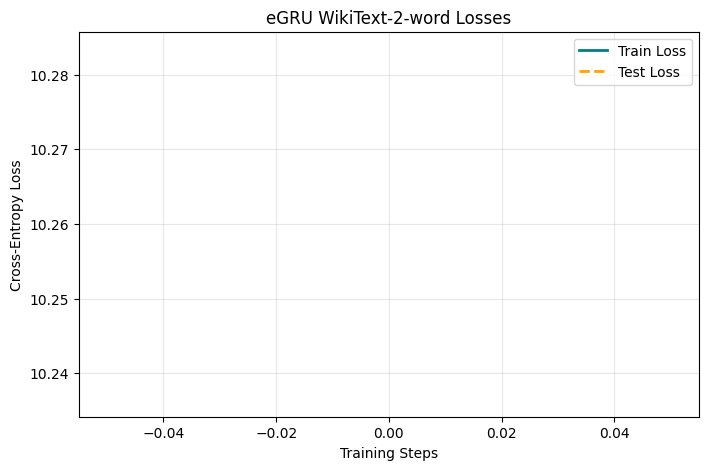

Step: 0
Training loss: 10.283385276794434
Validation loss: 10.236528790914095
PPL measurement: 27904.096665354602


  0%|          | 0/104 [00:00<?, ?it/s]

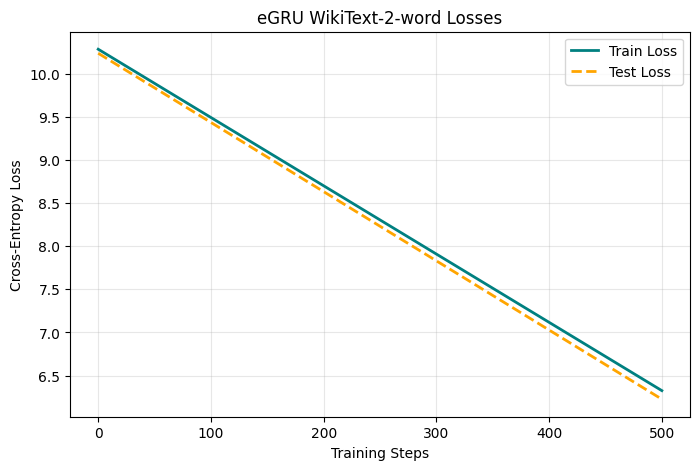

Step: 500
Training loss: 6.324743270874023
Validation loss: 6.225112208953271
PPL measurement: 505.27973618630375


  0%|          | 0/104 [00:00<?, ?it/s]

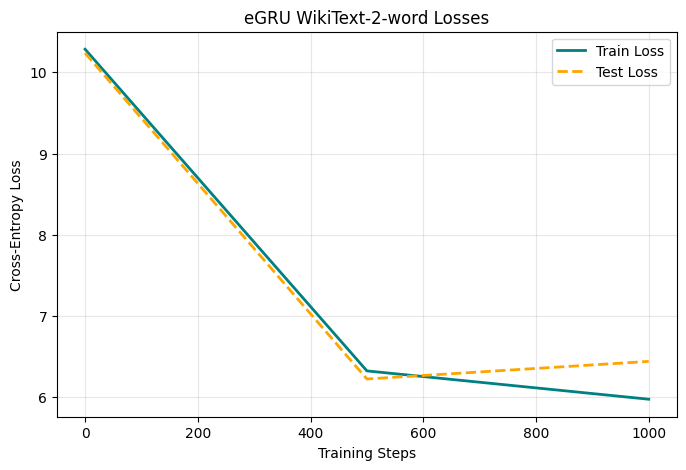

Step: 1000
Training loss: 5.976197719573975
Validation loss: 6.441842088332543
PPL measurement: 627.5617599115171


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

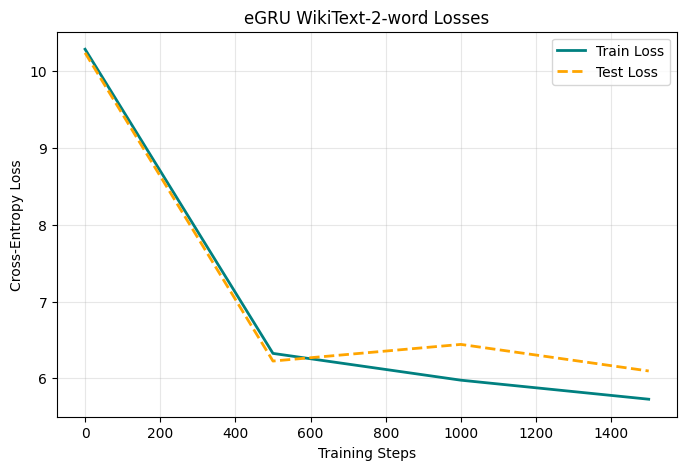

Step: 1500
Training loss: 5.72835636138916
Validation loss: 6.095815585209773
PPL measurement: 443.9960141311225


  0%|          | 0/104 [00:00<?, ?it/s]

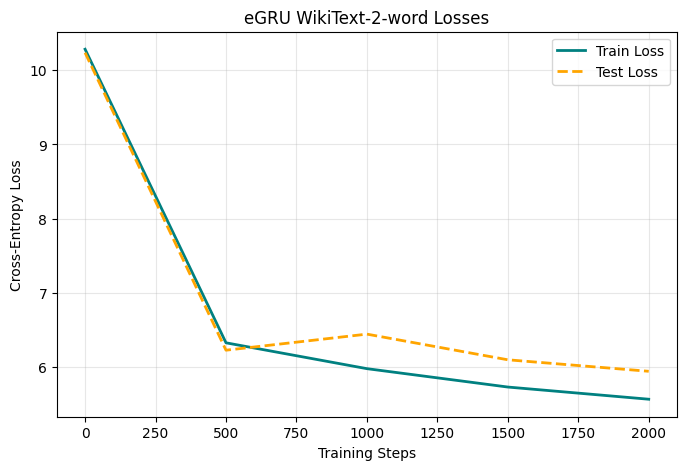

Step: 2000
Training loss: 5.56411600112915
Validation loss: 5.940664488535661
PPL measurement: 380.18747584088595


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

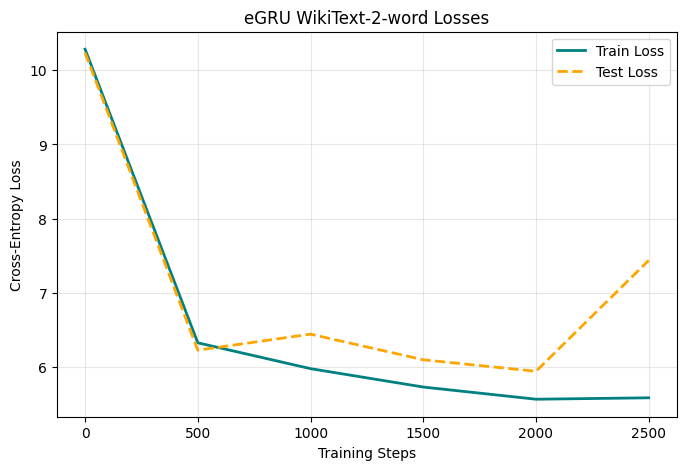

Step: 2500
Training loss: 5.583209037780762
Validation loss: 7.436517605414758
PPL measurement: 1696.8308857134514


  0%|          | 0/104 [00:00<?, ?it/s]

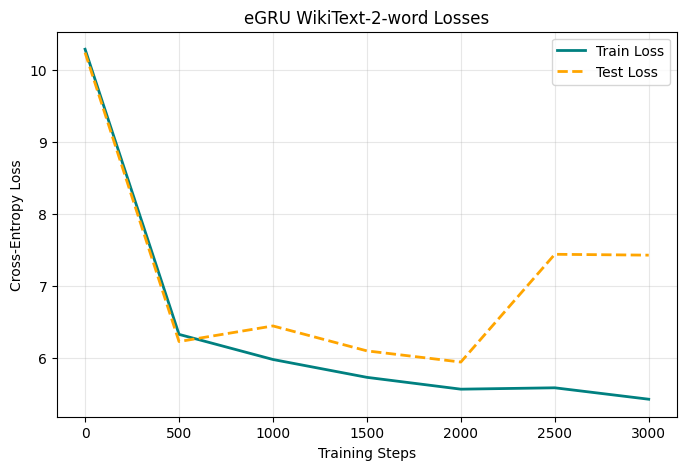

Step: 3000
Training loss: 5.424613952636719
Validation loss: 7.424670045192425
PPL measurement: 1676.8461982633714


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

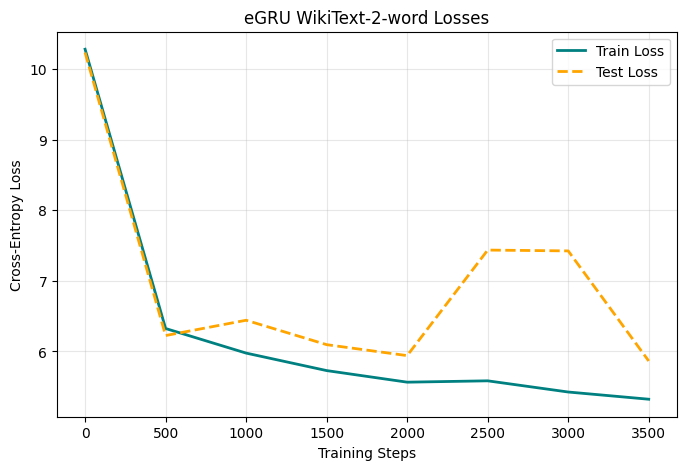

Step: 3500
Training loss: 5.322463512420654
Validation loss: 5.864469065116002
PPL measurement: 352.2950607071769


  0%|          | 0/104 [00:00<?, ?it/s]

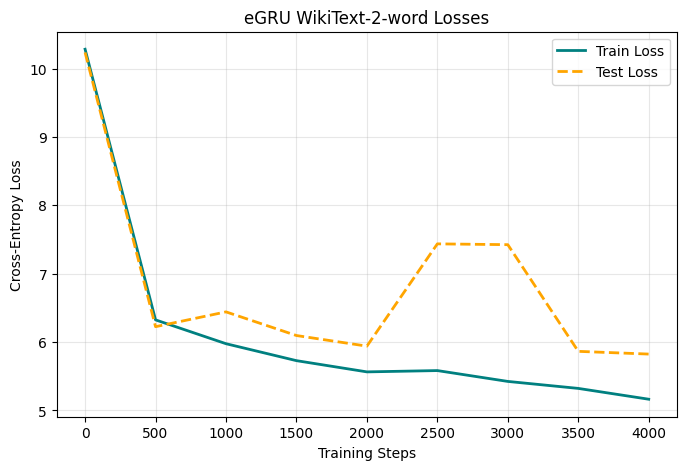

Step: 4000
Training loss: 5.164261817932129
Validation loss: 5.8245025002039394
PPL measurement: 338.4926911366772


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

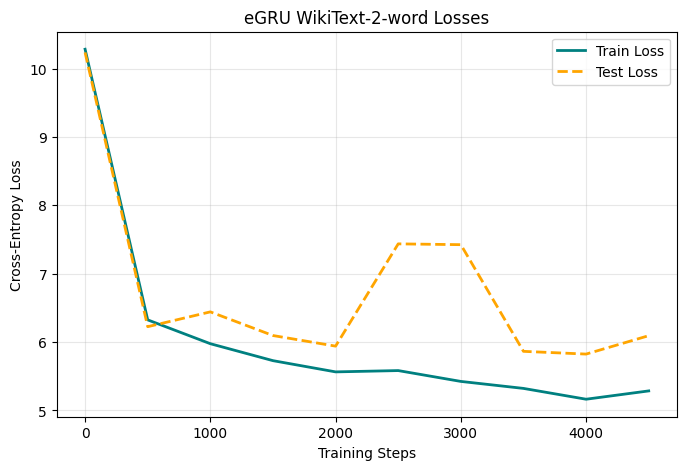

Step: 4500
Training loss: 5.285796165466309
Validation loss: 6.093681734341842
PPL measurement: 443.0496029602692


  0%|          | 0/104 [00:00<?, ?it/s]

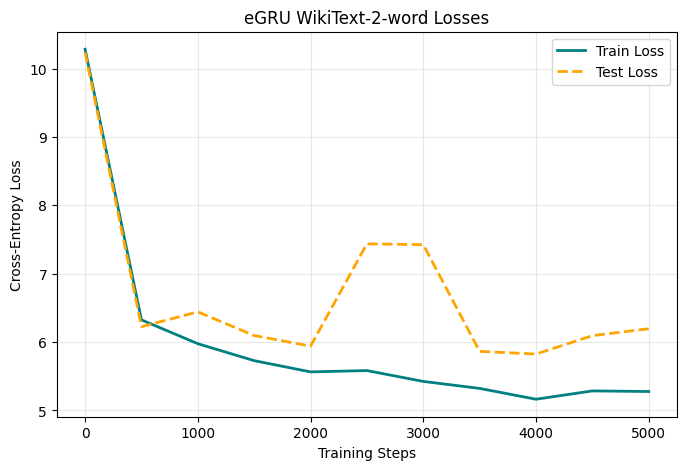

Step: 5000
Training loss: 5.2770280838012695
Validation loss: 6.1949003751461325
PPL measurement: 490.2426022174752


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

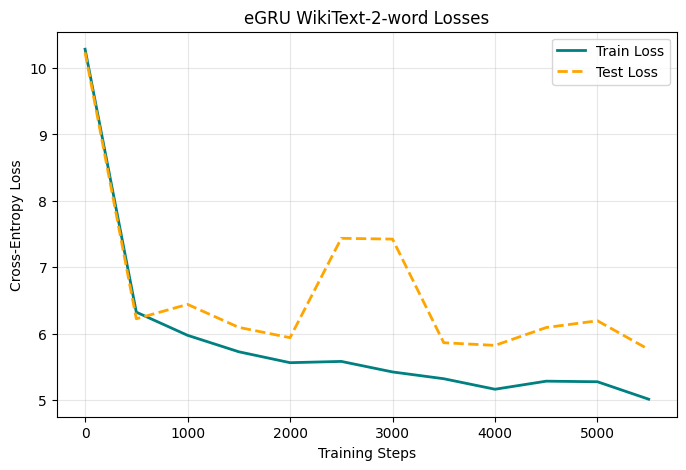

Step: 5500
Training loss: 5.014028549194336
Validation loss: 5.763120990533095
PPL measurement: 318.3403172359598


  0%|          | 0/104 [00:00<?, ?it/s]

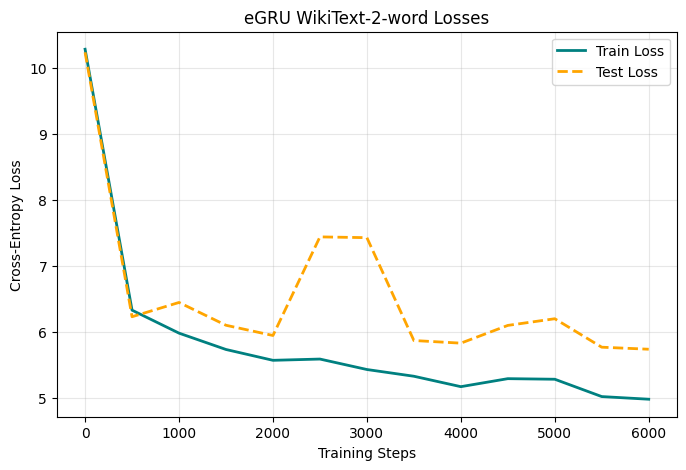

Step: 6000
Training loss: 4.973909378051758
Validation loss: 5.732195661618159
PPL measurement: 308.64620757230745


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

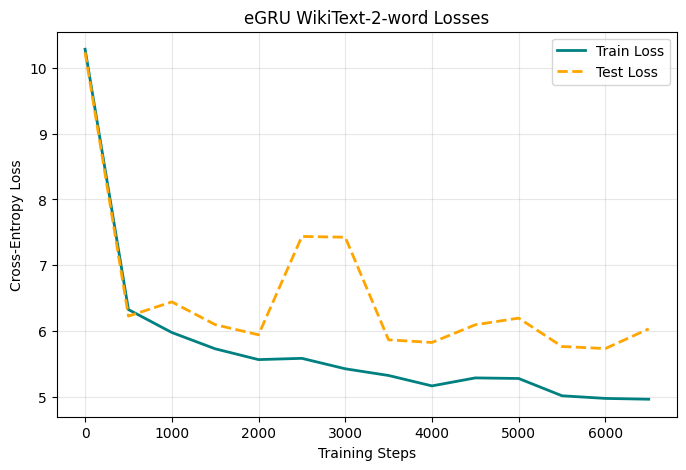

Step: 6500
Training loss: 4.961645126342773
Validation loss: 6.031593611607184
PPL measurement: 416.37804583313


  0%|          | 0/104 [00:00<?, ?it/s]

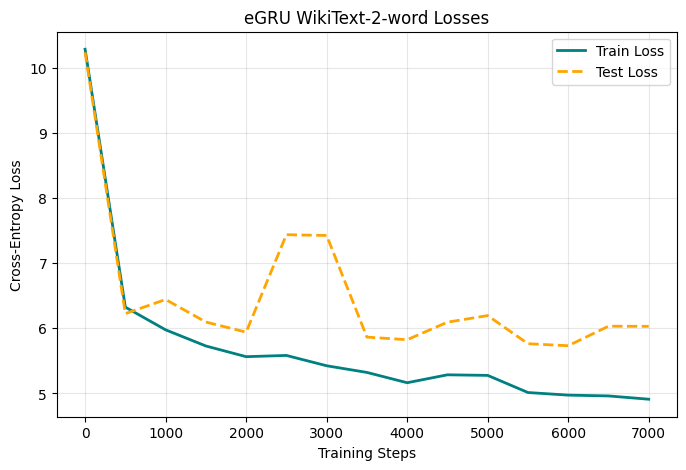

Step: 7000
Training loss: 4.911118507385254
Validation loss: 6.0298251280417805
PPL measurement: 415.6423388366909


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

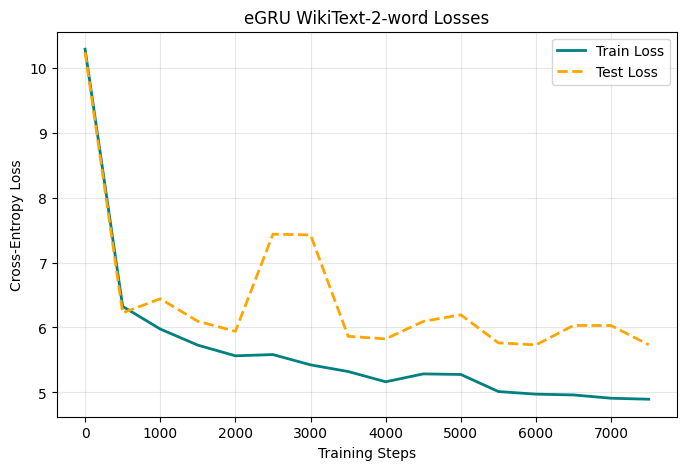

Step: 7500
Training loss: 4.895876884460449
Validation loss: 5.734087224190052
PPL measurement: 309.23058370427555


  0%|          | 0/104 [00:00<?, ?it/s]

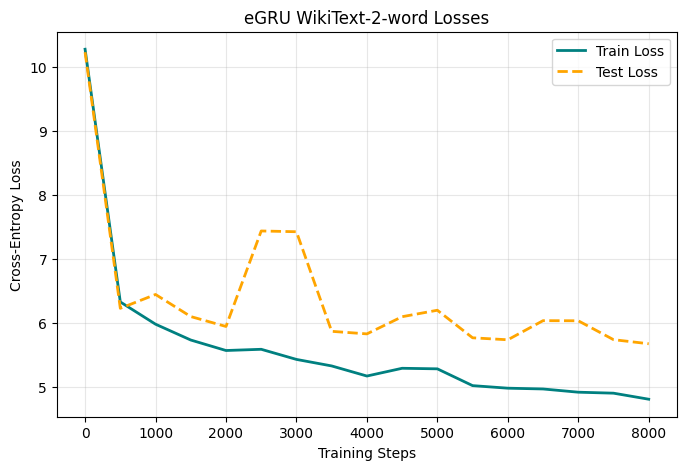

Step: 8000
Training loss: 4.801112174987793
Validation loss: 5.669862985610962
PPL measurement: 289.9947982094816


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

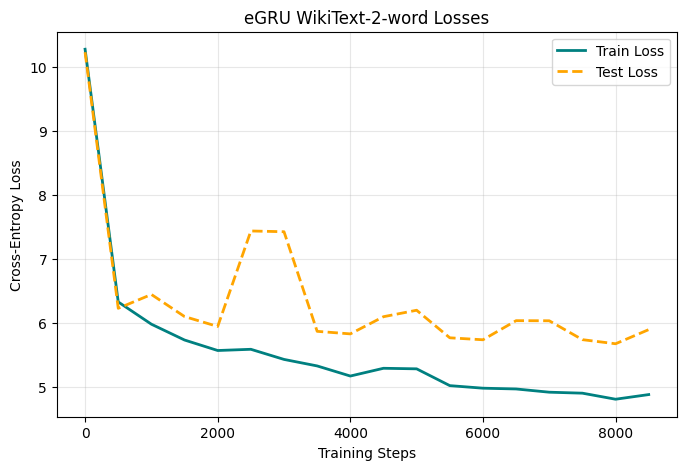

Step: 8500
Training loss: 4.873973369598389
Validation loss: 5.8914044957894545
PPL measurement: 361.9132331949662


  0%|          | 0/104 [00:00<?, ?it/s]

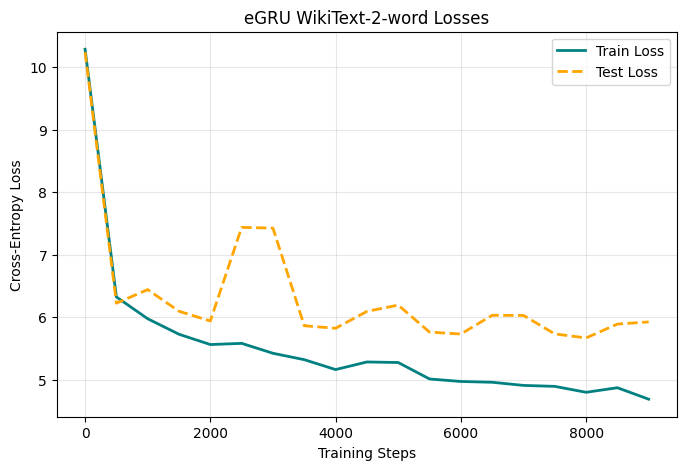

Step: 9000
Training loss: 4.6904730796813965
Validation loss: 5.925869176020989
PPL measurement: 374.60389061992504


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

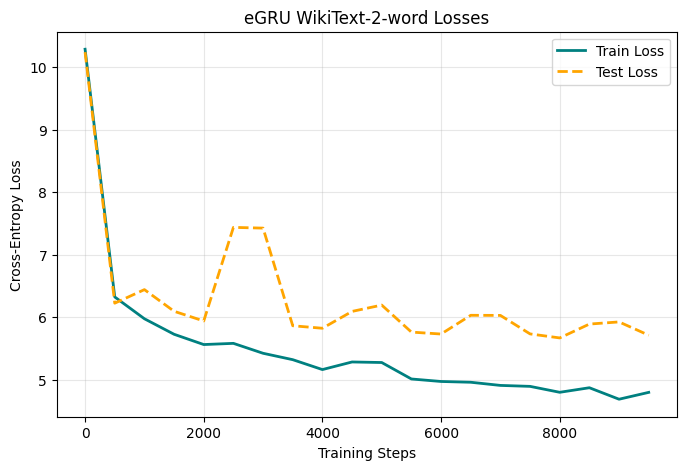

Step: 9500
Training loss: 4.800043106079102
Validation loss: 5.713355642098647
PPL measurement: 302.8857410350561


  0%|          | 0/104 [00:00<?, ?it/s]

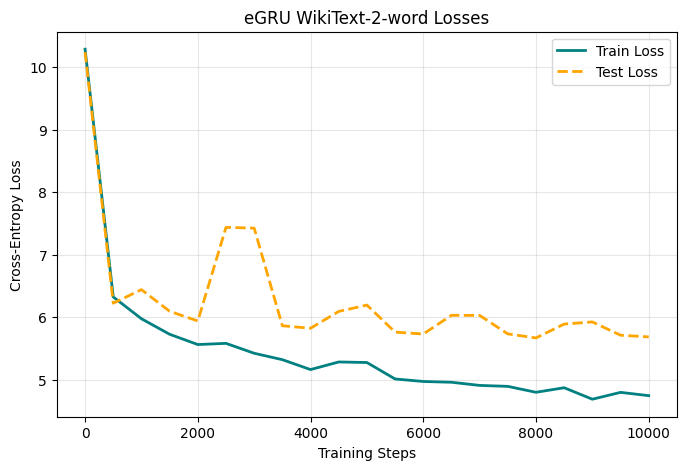

Step: 10000
Training loss: 4.747348785400391
Validation loss: 5.686187157264123
PPL measurement: 294.7675728841215


In [ ]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)
lr=1e-3
epochs = 10
break_time=500
start_step =0

steps_history = []
train_history = []
test_history = []
ppl_history=[]




eGRU_model = custom_models_for_lm.eGRU(vocab, hid, emb, device='cuda')
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)
cell_state = eGRU_model.eGRUCell.init_hid.unsqueeze(0).expand(batch_size, -1)

for epoch in trange(epochs):

    start_step = train_model(
        model=eGRU_model,
        model_name="eGRU",
        cell_state=cell_state,
        opt=opt_eGRU,
        encoded_data=train_data_chunked,
        encoded_eval_data=validation_data_chunked,
        train_loss_history=train_history,
        test_loss_history=test_history,
        ppl_history=ppl_history,
        start_step=start_step,
        recorded_steps=steps_history,
        break_time=break_time,
        hid=hid,
        device='cuda'
    )


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

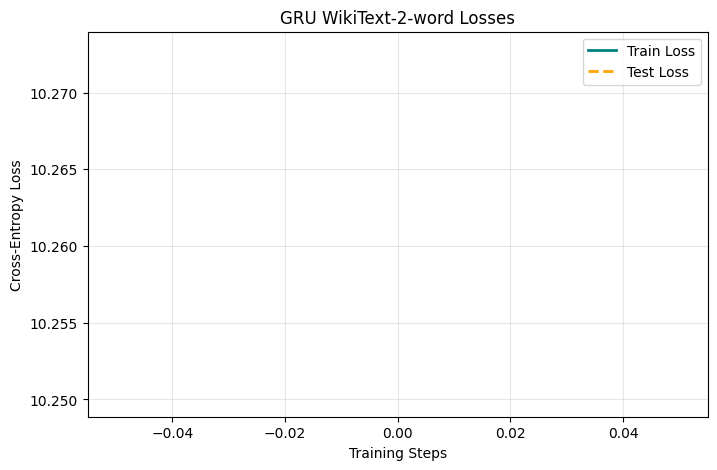

Step: 0
Training loss: 10.272821426391602
Validation loss: 10.250017037758461
PPL measurement: 28283.023795557903


  0%|          | 0/104 [00:00<?, ?it/s]

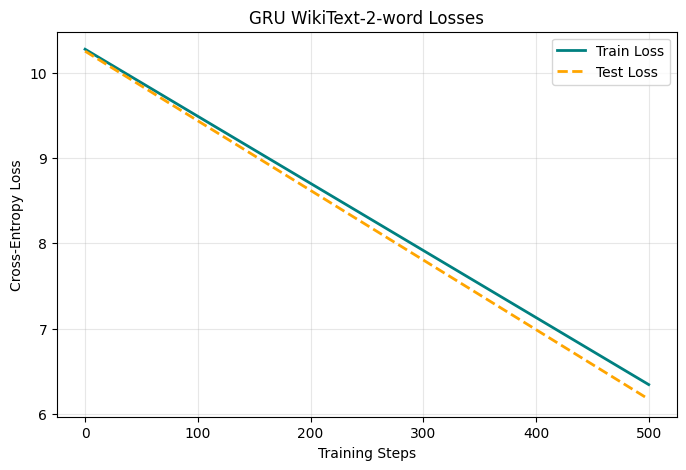

Step: 500
Training loss: 6.343381404876709
Validation loss: 6.172014846251561
PPL measurement: 479.150548848331


  0%|          | 0/104 [00:00<?, ?it/s]

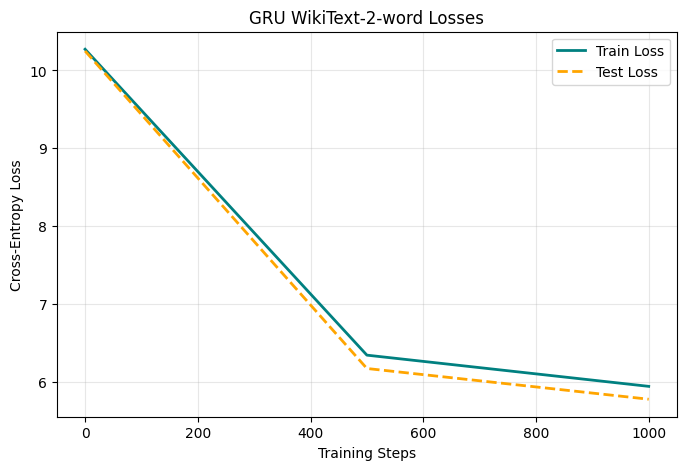

Step: 1000
Training loss: 5.942524433135986
Validation loss: 5.777279124810145
PPL measurement: 322.8794794032054


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

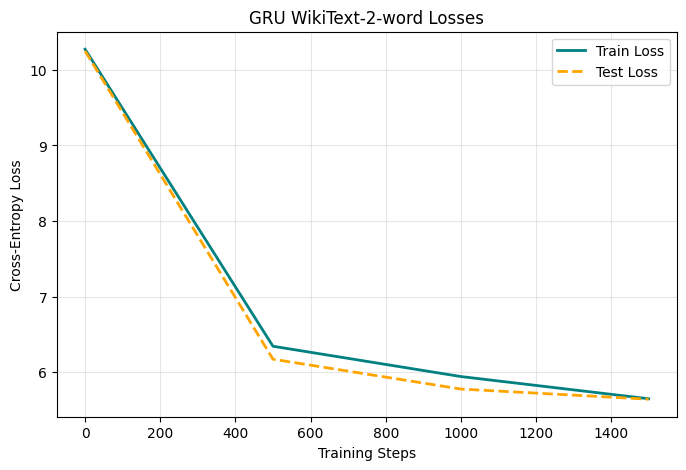

Step: 1500
Training loss: 5.648613452911377
Validation loss: 5.6425320001748895
PPL measurement: 282.176285121897


  0%|          | 0/104 [00:00<?, ?it/s]

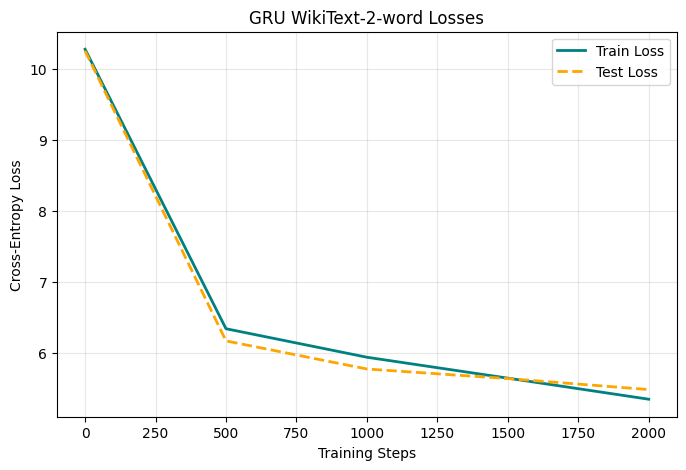

Step: 2000
Training loss: 5.352355003356934
Validation loss: 5.487840524086585
PPL measurement: 241.73462271191332


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

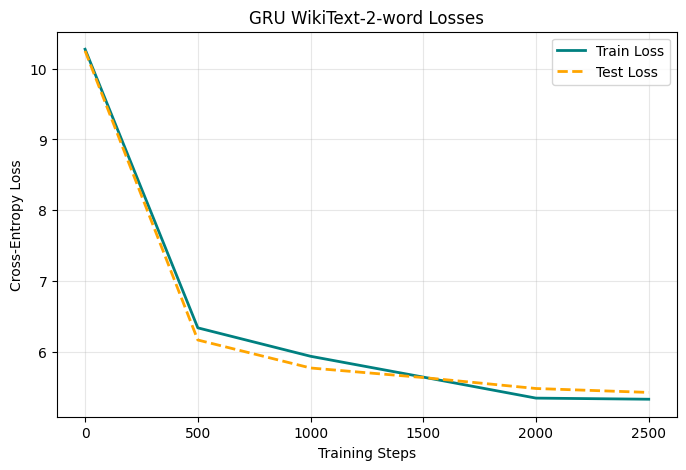

Step: 2500
Training loss: 5.336703300476074
Validation loss: 5.432509050919459
PPL measurement: 228.722402237139


  0%|          | 0/104 [00:00<?, ?it/s]

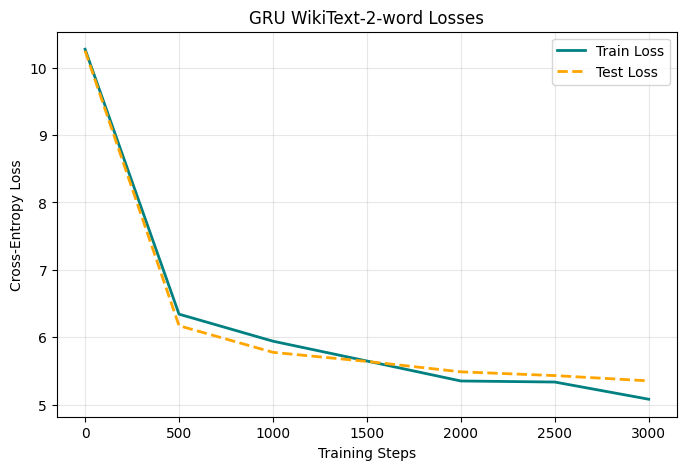

Step: 3000
Training loss: 5.081807613372803
Validation loss: 5.354148603402651
PPL measurement: 211.48384305696467


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

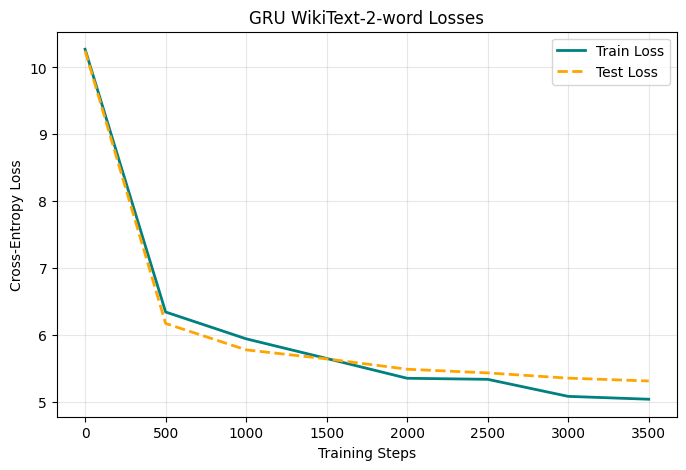

Step: 3500
Training loss: 5.03914213180542
Validation loss: 5.311895636411814
PPL measurement: 202.73417464529768


  0%|          | 0/104 [00:00<?, ?it/s]

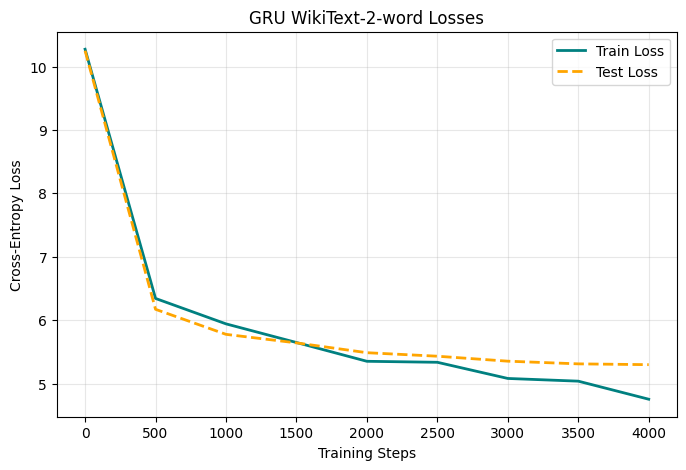

Step: 4000
Training loss: 4.7543864250183105
Validation loss: 5.299228723232563
PPL measurement: 200.1823544192432


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

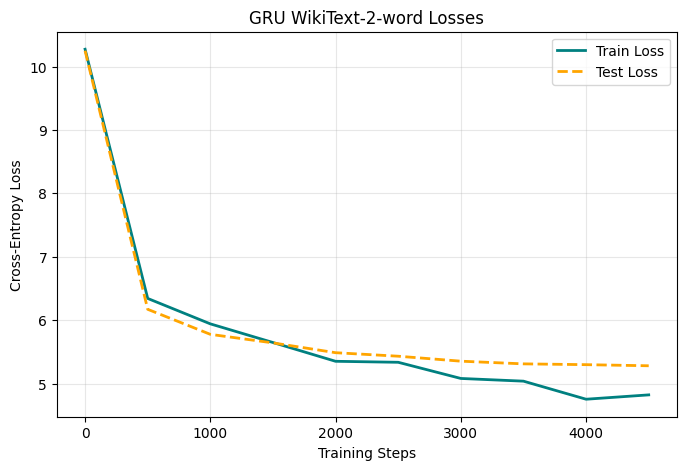

Step: 4500
Training loss: 4.8228960037231445
Validation loss: 5.281719643336076
PPL measurement: 196.7078520157241


  0%|          | 0/104 [00:00<?, ?it/s]

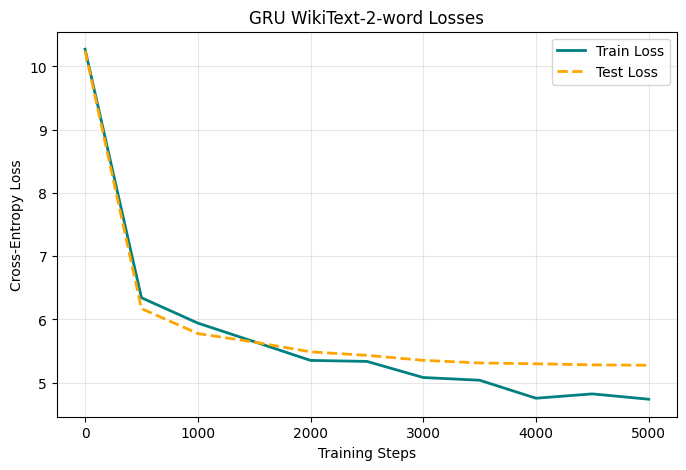

Step: 5000
Training loss: 4.738700866699219
Validation loss: 5.275826472502488
PPL measurement: 195.5520281184208


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

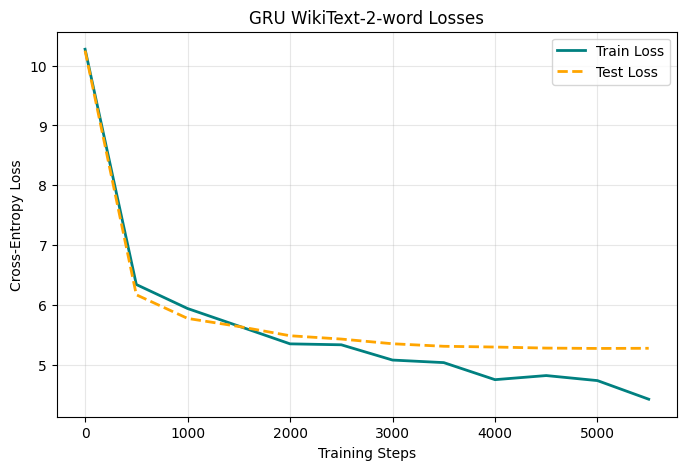

Step: 5500
Training loss: 4.427746772766113
Validation loss: 5.278496934817388
PPL measurement: 196.07494033804483


  0%|          | 0/104 [00:00<?, ?it/s]

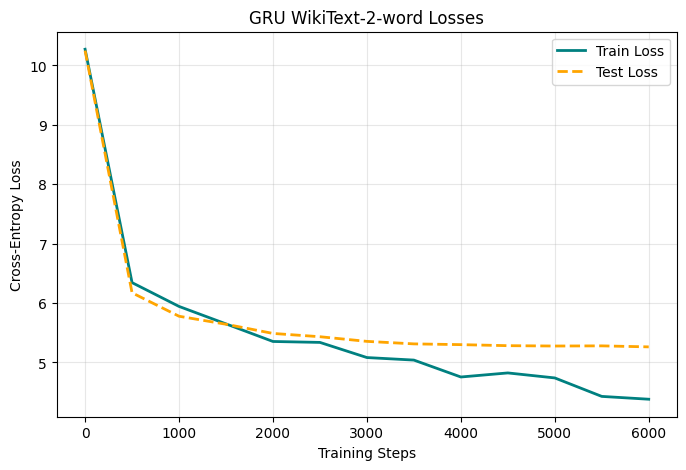

Step: 6000
Training loss: 4.380209922790527
Validation loss: 5.261417618164649
PPL measurement: 192.75455005646674


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

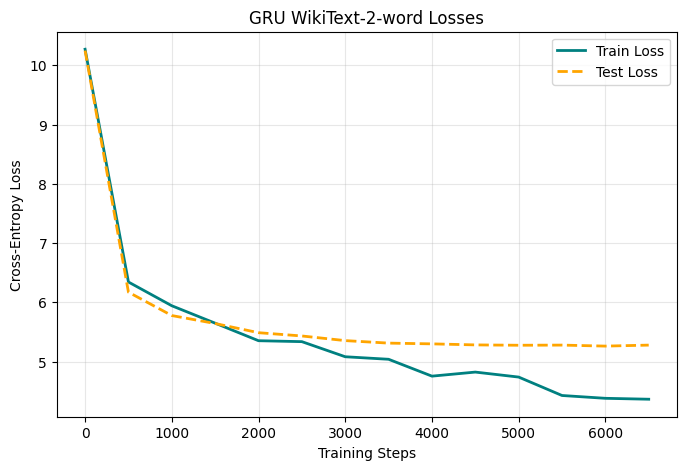

Step: 6500
Training loss: 4.364808559417725
Validation loss: 5.278280895489913
PPL measurement: 196.03258501517203


  0%|          | 0/104 [00:00<?, ?it/s]

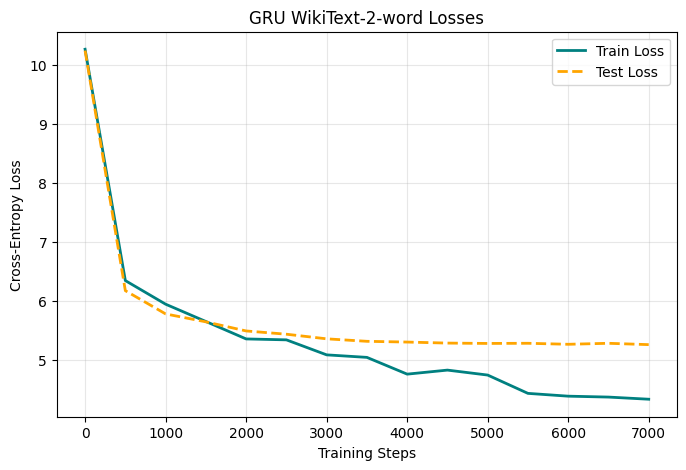

Step: 7000
Training loss: 4.328378200531006
Validation loss: 5.255412835341233
PPL measurement: 191.60056901538198


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

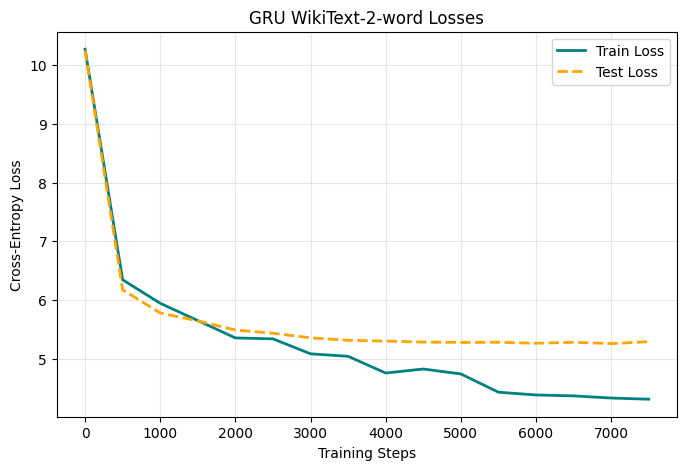

Step: 7500
Training loss: 4.30795431137085
Validation loss: 5.289277934111082
PPL measurement: 198.20026008122218


  0%|          | 0/104 [00:00<?, ?it/s]

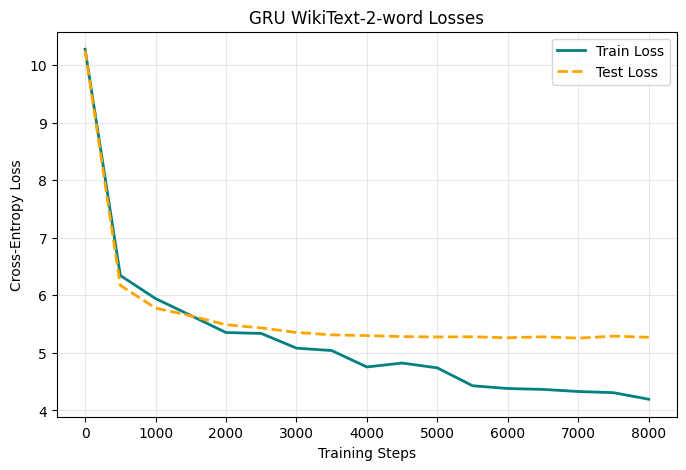

Step: 8000
Training loss: 4.194277763366699
Validation loss: 5.2694012476847725
PPL measurement: 194.29959028028975


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

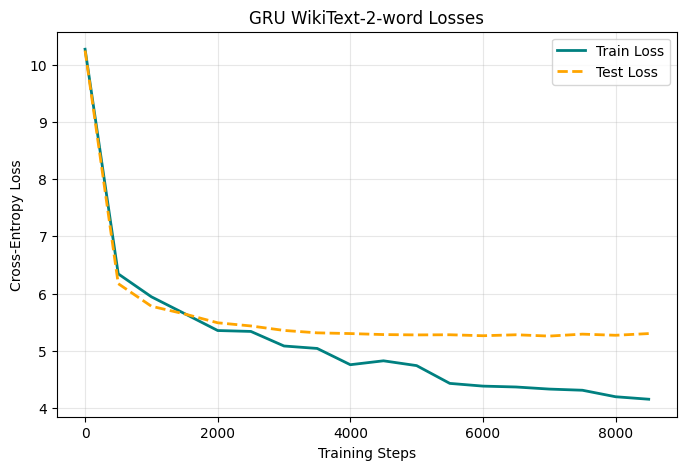

Step: 8500
Training loss: 4.150900840759277
Validation loss: 5.299220672020545
PPL measurement: 200.18074271515363


  0%|          | 0/104 [00:00<?, ?it/s]

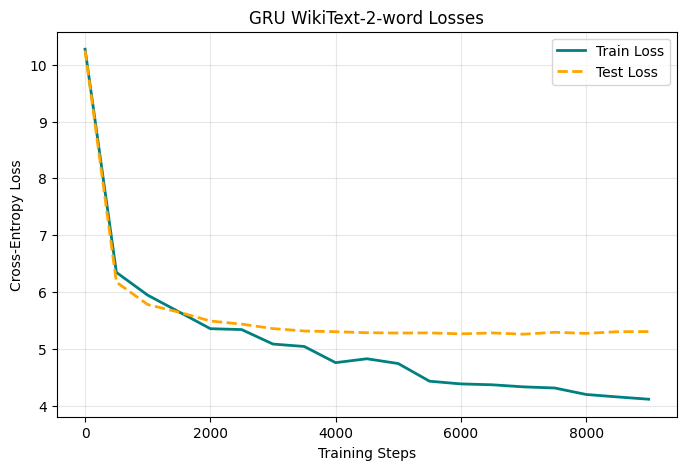

Step: 9000
Training loss: 4.110558032989502
Validation loss: 5.301390955081353
PPL measurement: 200.61566336992223


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

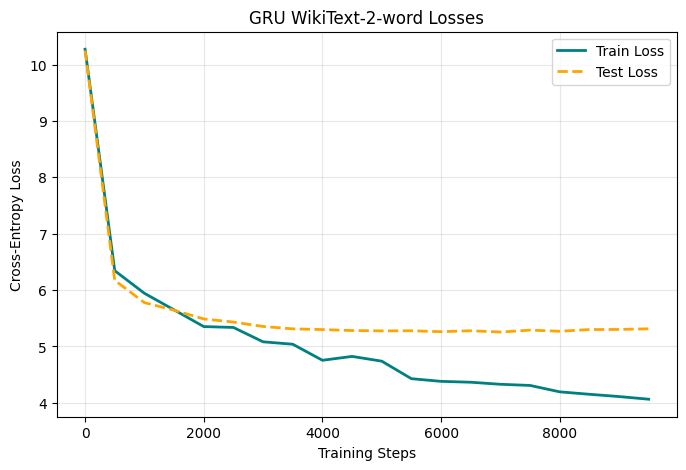

Step: 9500
Training loss: 4.063383102416992
Validation loss: 5.3127440214157104
PPL measurement: 202.90624425916346


  0%|          | 0/104 [00:00<?, ?it/s]

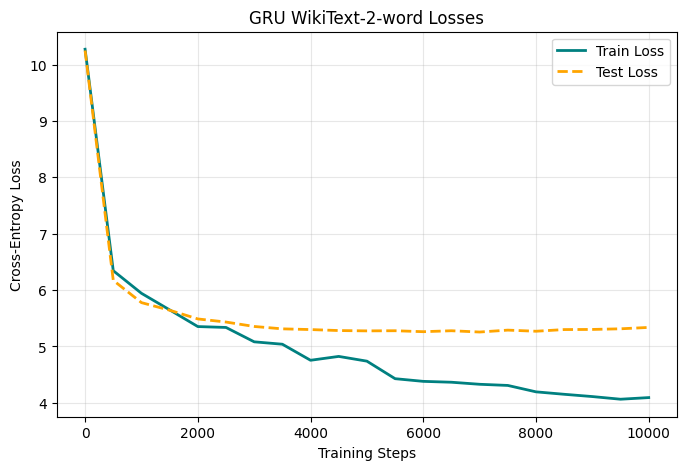

Step: 10000
Training loss: 4.092401504516602
Validation loss: 5.337335169315338
PPL measurement: 207.95779892137955


In [35]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)
lr=1e-3
epochs = 10
break_time=500
start_step =0

steps_history = []
train_history = []
test_history = []
ppl_history=[]




GRU_model = custom_models_for_lm.GRU_LM(vocab, hid, emb, device='cuda')
opt_GRU = torch.optim.Adam(GRU_model.parameters(), lr=lr)
hid_state = GRU_model.init_hid.unsqueeze(0).expand(batch_size, -1)

for epoch in trange(epochs):

    start_step = train_model_hid_state(
        model=GRU_model,
        model_name="GRU",
        hid_state=hid_state,
        opt=opt_GRU,
        encoded_data=train_data_chunked,
        encoded_eval_data=validation_data_chunked,
        train_loss_history=train_history,
        test_loss_history=test_history,
        ppl_history=ppl_history,
        start_step=start_step,
        recorded_steps=steps_history,
        break_time=break_time,
        hid=hid,
        device='cuda'
    )


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

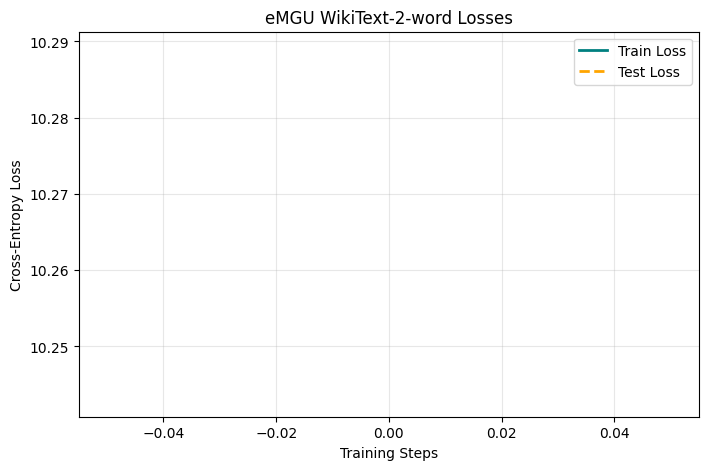

Step: 0
Training loss: 10.28897762298584
Validation loss: 10.243085787846493
PPL measurement: 28087.664912108936


  0%|          | 0/104 [00:00<?, ?it/s]

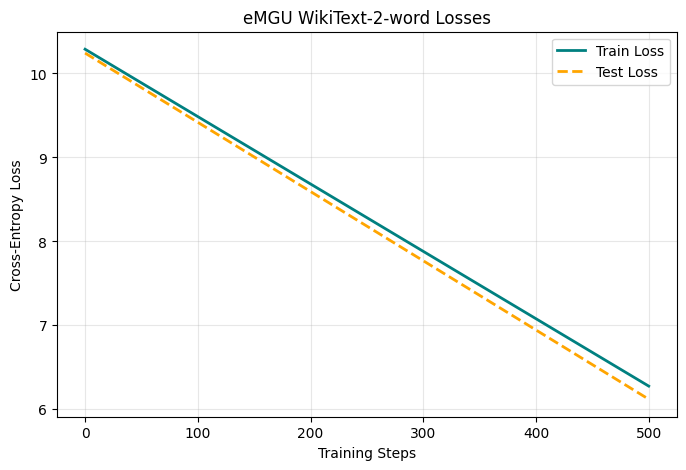

Step: 500
Training loss: 6.27675724029541
Validation loss: 6.120568114977616
PPL measurement: 455.1231833640044


  0%|          | 0/104 [00:00<?, ?it/s]

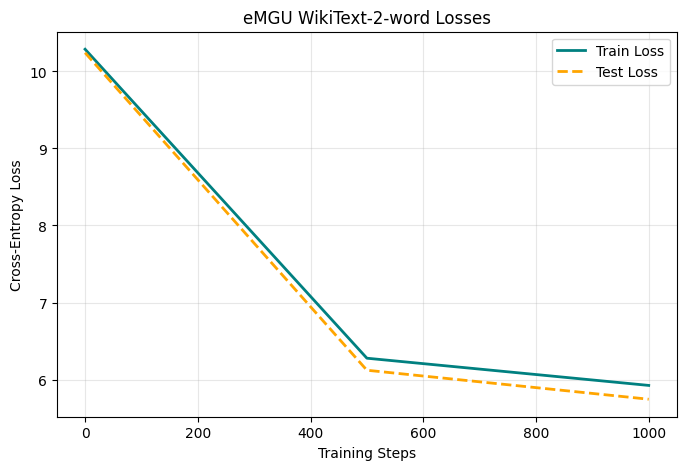

Step: 1000
Training loss: 5.923402786254883
Validation loss: 5.744137108325958
PPL measurement: 312.35398385799135


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

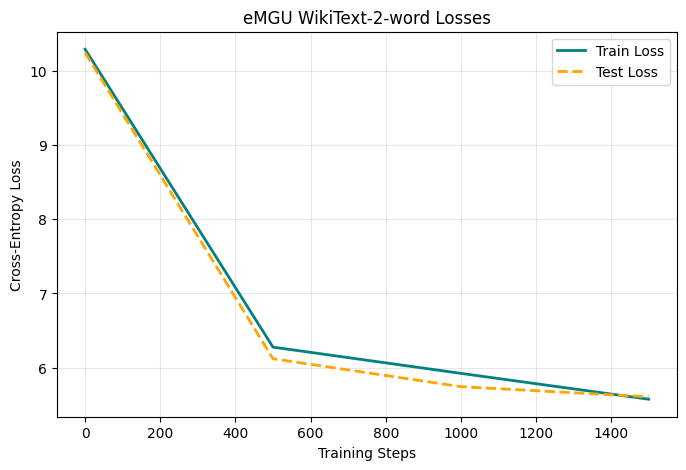

Step: 1500
Training loss: 5.574962139129639
Validation loss: 5.607642155427199
PPL measurement: 272.5009650124716


  0%|          | 0/104 [00:00<?, ?it/s]

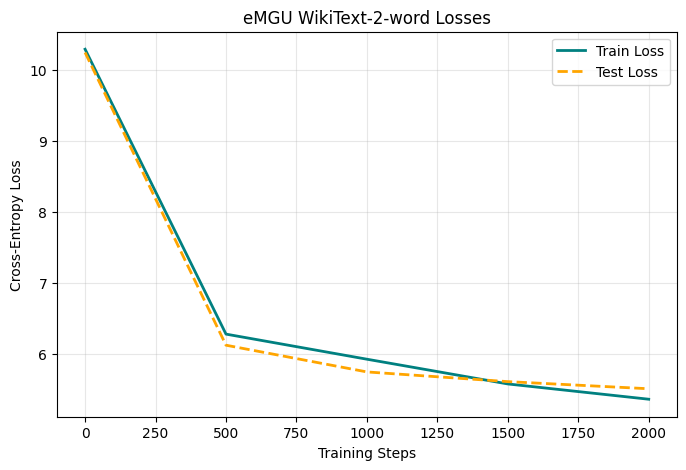

Step: 2000
Training loss: 5.359786033630371
Validation loss: 5.507199901800889
PPL measurement: 246.46004763848276


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

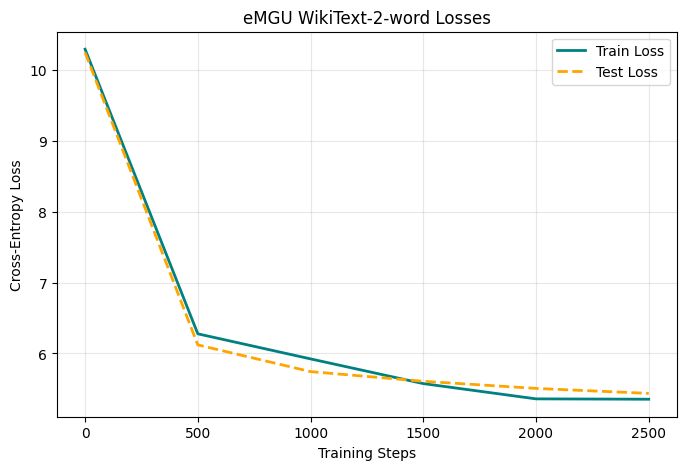

Step: 2500
Training loss: 5.354745388031006
Validation loss: 5.4370729097953205
PPL measurement: 229.76864463803318


  0%|          | 0/104 [00:00<?, ?it/s]

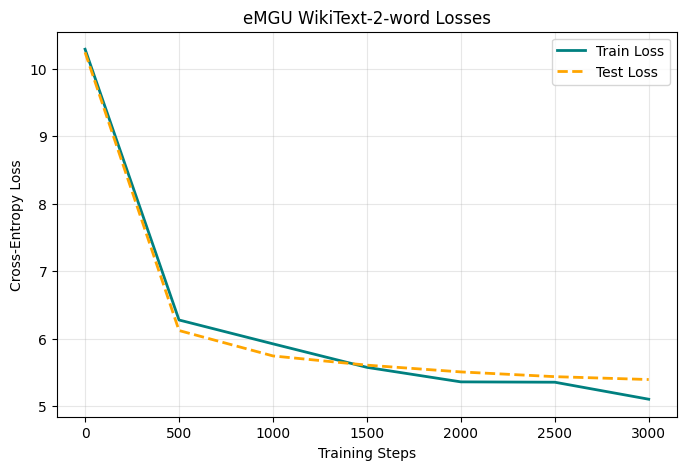

Step: 3000
Training loss: 5.102678298950195
Validation loss: 5.3944530211962185
PPL measurement: 220.18167944123624


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

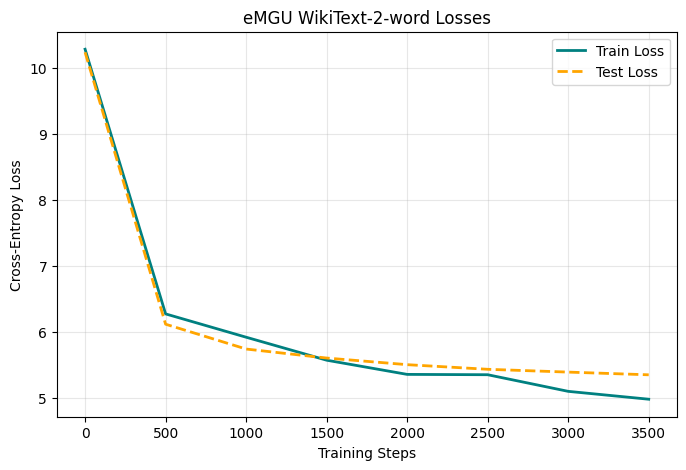

Step: 3500
Training loss: 4.983379364013672
Validation loss: 5.353422871002784
PPL measurement: 211.33041805948955


  0%|          | 0/104 [00:00<?, ?it/s]

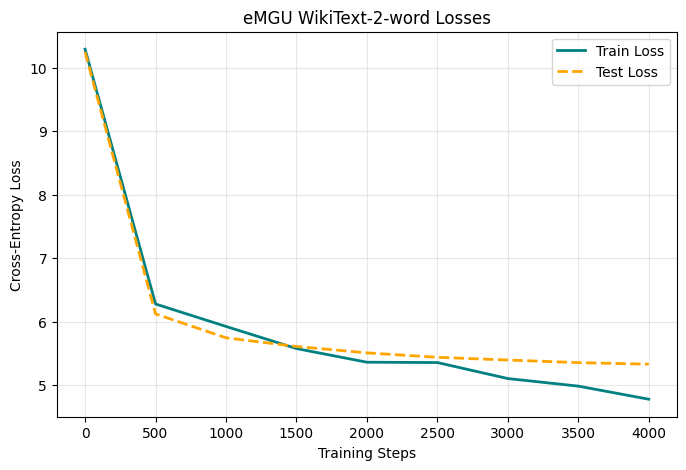

Step: 4000
Training loss: 4.777143478393555
Validation loss: 5.328919131022233
PPL measurement: 206.21496229922028


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

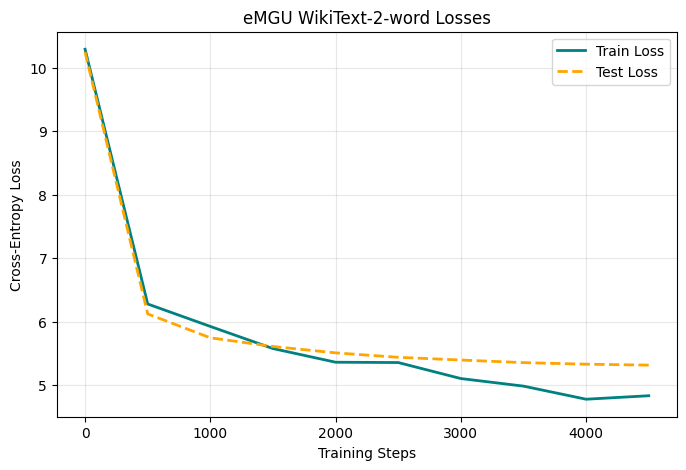

Step: 4500
Training loss: 4.8320536613464355
Validation loss: 5.313918333787185
PPL measurement: 203.1446595316503


  0%|          | 0/104 [00:00<?, ?it/s]

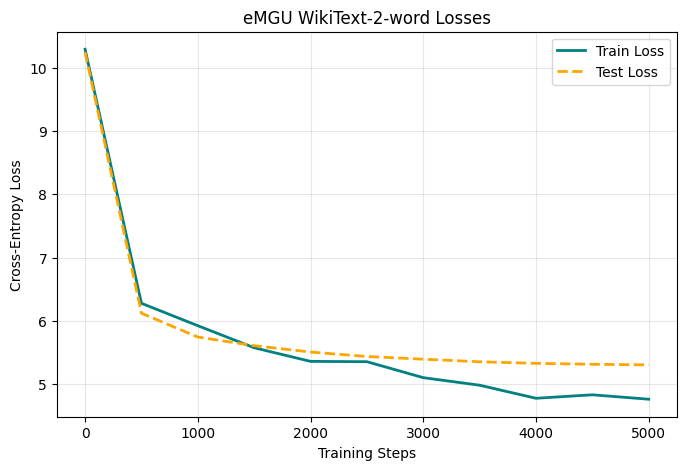

Step: 5000
Training loss: 4.76224946975708
Validation loss: 5.30459326505661
PPL measurement: 201.25912664447432


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

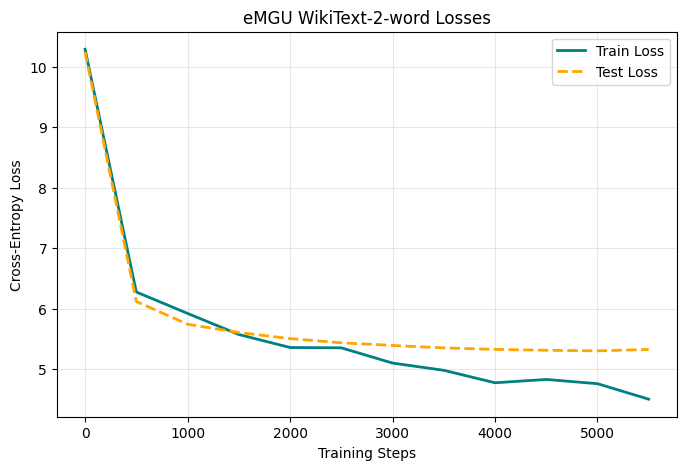

Step: 5500
Training loss: 4.505336284637451
Validation loss: 5.327488587452815
PPL measurement: 205.92017371521456


  0%|          | 0/104 [00:00<?, ?it/s]

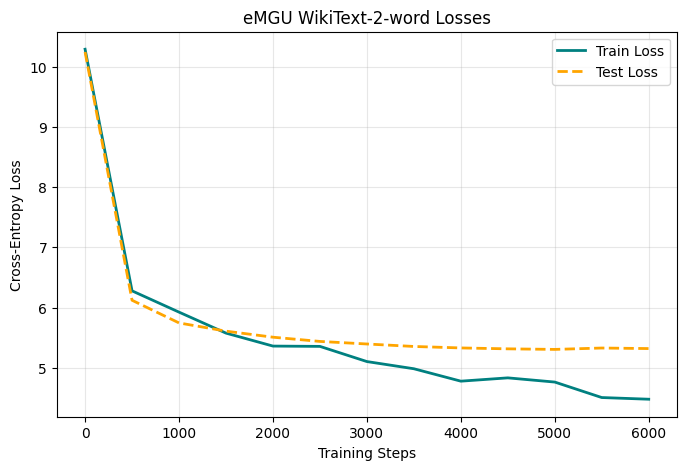

Step: 6000
Training loss: 4.477379322052002
Validation loss: 5.318489996286539
PPL measurement: 204.07549446394057


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

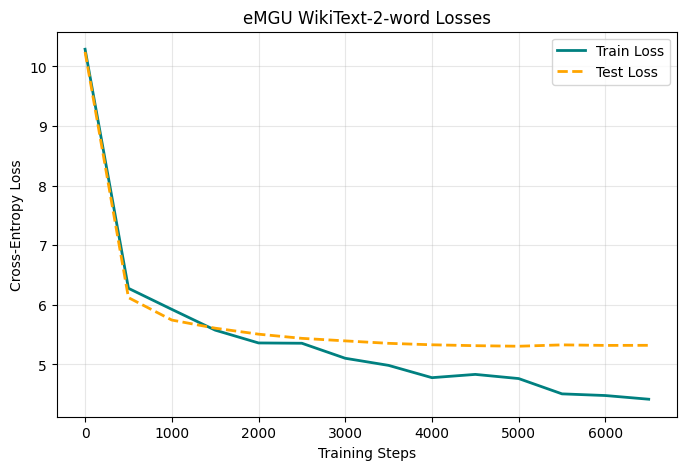

Step: 6500
Training loss: 4.415457248687744
Validation loss: 5.320033476902888
PPL measurement: 204.39072424686552


  0%|          | 0/104 [00:00<?, ?it/s]

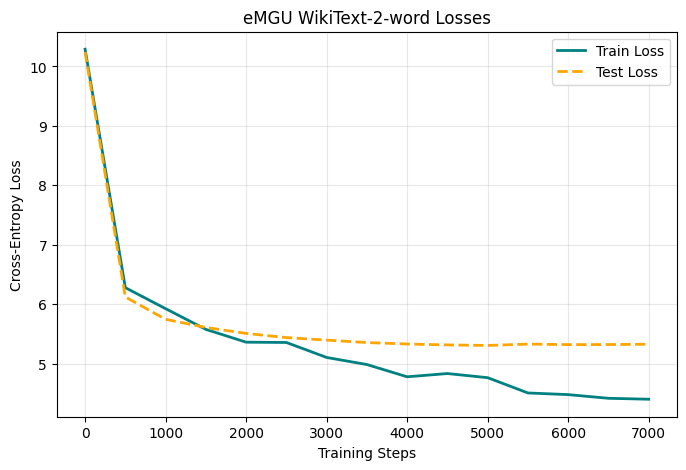

Step: 7000
Training loss: 4.399957656860352
Validation loss: 5.325309547094198
PPL measurement: 205.47195386795784


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

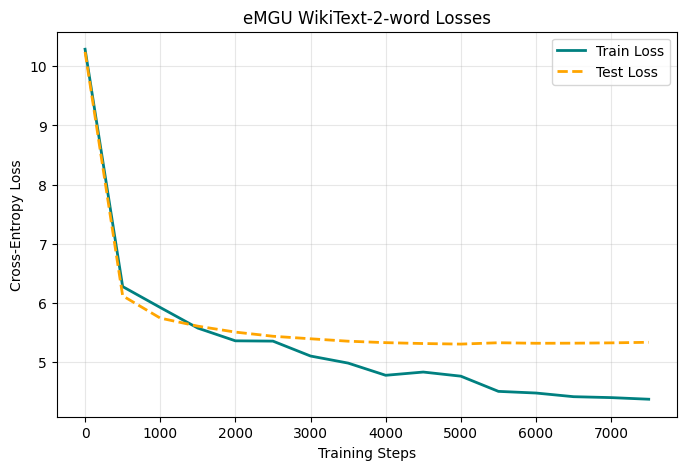

Step: 7500
Training loss: 4.372654438018799
Validation loss: 5.3350740029261665
PPL measurement: 207.48810296657015


  0%|          | 0/104 [00:00<?, ?it/s]

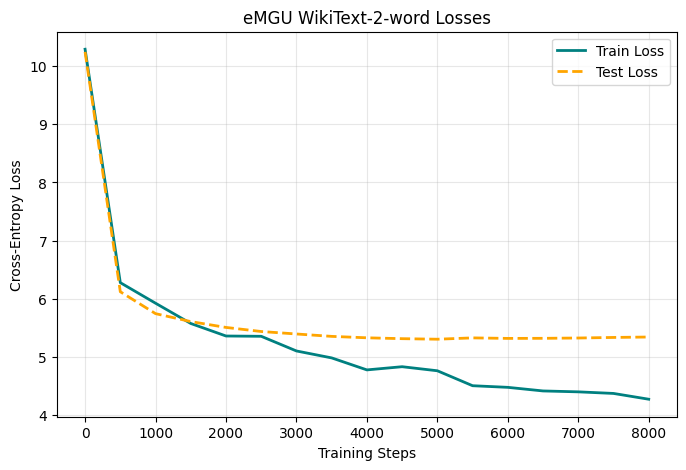

Step: 8000
Training loss: 4.273204326629639
Validation loss: 5.342335627629207
PPL measurement: 209.00028751405645


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

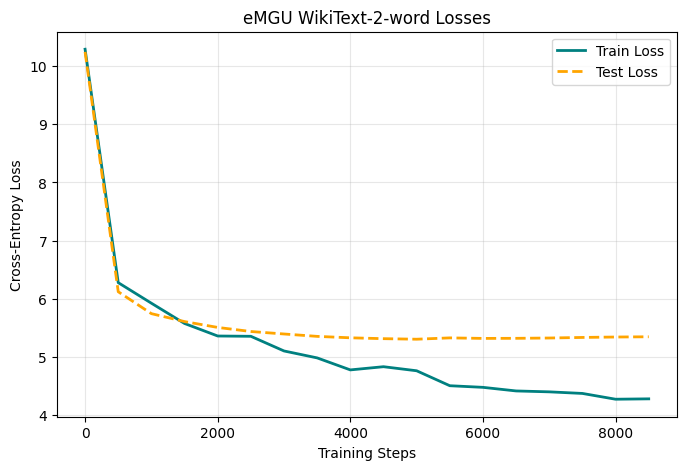

Step: 8500
Training loss: 4.279589653015137
Validation loss: 5.34643181012227
PPL measurement: 209.85814660703528


  0%|          | 0/104 [00:00<?, ?it/s]

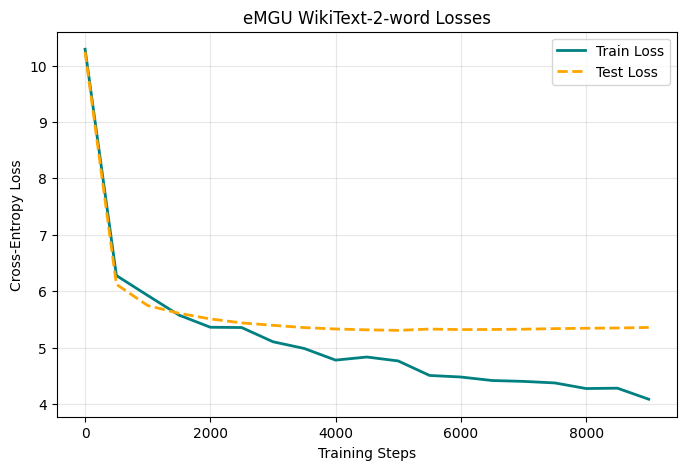

Step: 9000
Training loss: 4.083764553070068
Validation loss: 5.356526420666621
PPL measurement: 211.98731133059468


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

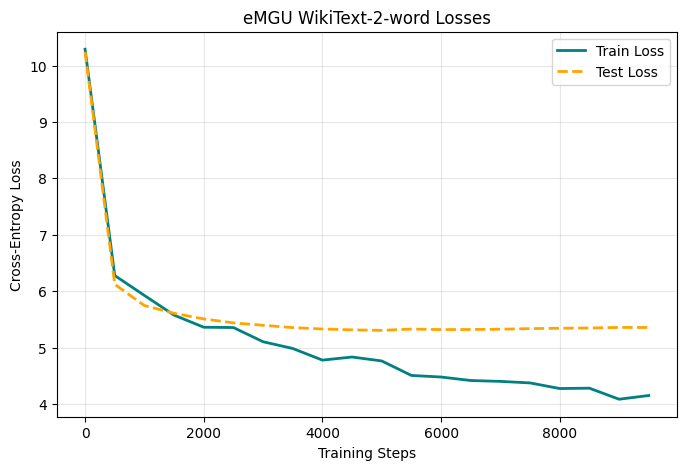

Step: 9500
Training loss: 4.149508953094482
Validation loss: 5.355908416784727
PPL measurement: 211.85634282297153


  0%|          | 0/104 [00:00<?, ?it/s]

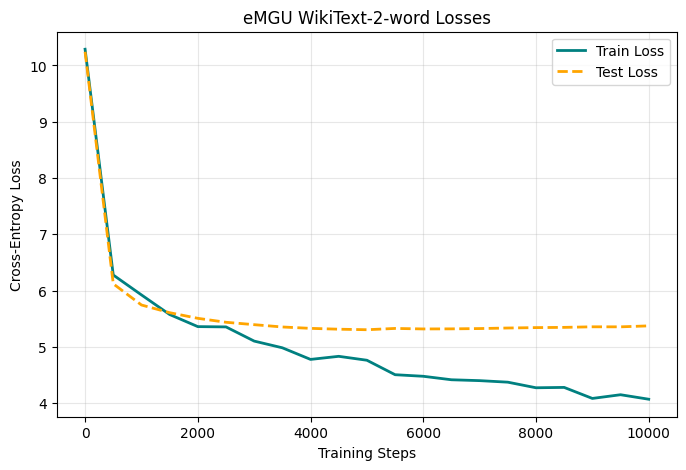

Step: 10000
Training loss: 4.0696916580200195
Validation loss: 5.373104764864995
PPL measurement: 215.5310030516405


In [15]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)
lr=1e-3
epochs = 10
break_time=500
start_step =0

steps_history = []
train_history = []
test_history = []
ppl_history=[]




eMGU_model = custom_models_for_lm.eMGU(vocab, hid, emb, device='cuda')
opt_eMGU = torch.optim.Adam(eMGU_model.parameters(), lr=lr)
hid_state = eMGU_model.init_hid.unsqueeze(0).expand(batch_size, -1)

for epoch in trange(epochs):

    start_step = train_model_hid_state(
        model=eMGU_model,
        model_name="eMGU",
        hid_state=hid_state,
        opt=opt_eMGU,
        encoded_data=train_data_chunked,
        encoded_eval_data=validation_data_chunked,
        train_loss_history=train_history,
        test_loss_history=test_history,
        ppl_history=ppl_history,
        start_step=start_step,
        recorded_steps=steps_history,
        break_time=break_time,
        hid=hid,
        device='cuda'
    )


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

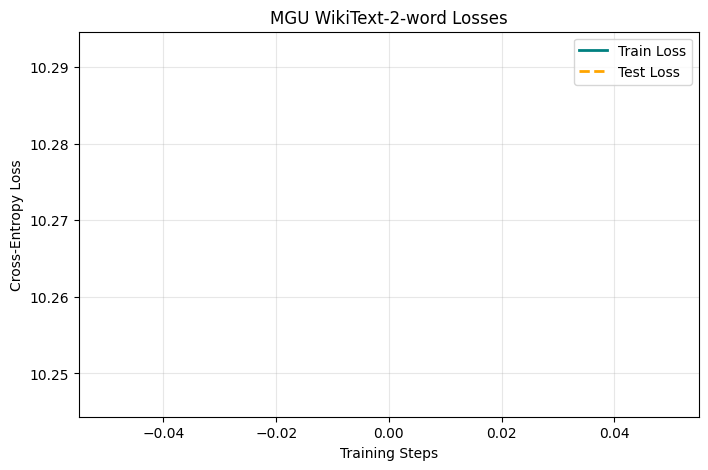

Step: 0
Training loss: 10.292360305786133
Validation loss: 10.246628458683308
PPL measurement: 28187.34672914554


  0%|          | 0/104 [00:00<?, ?it/s]

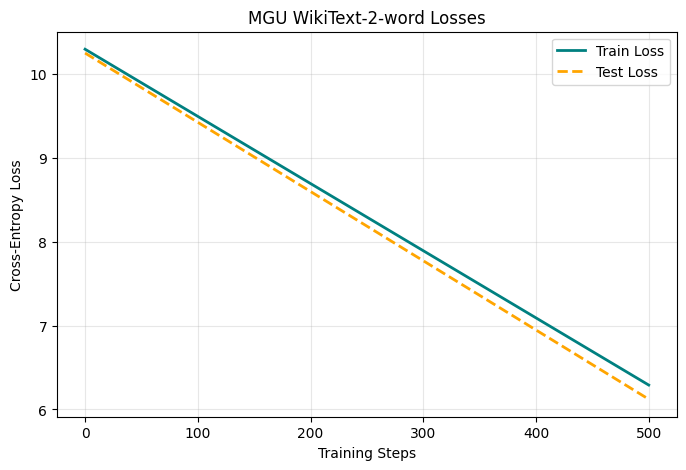

Step: 500
Training loss: 6.291160583496094
Validation loss: 6.122270987584041
PPL measurement: 455.8988604176659


  0%|          | 0/104 [00:00<?, ?it/s]

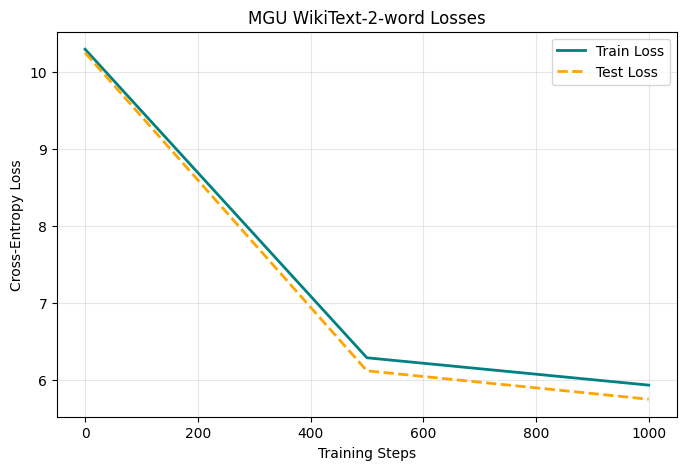

Step: 1000
Training loss: 5.936402320861816
Validation loss: 5.753626782160539
PPL measurement: 315.33223022887097


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

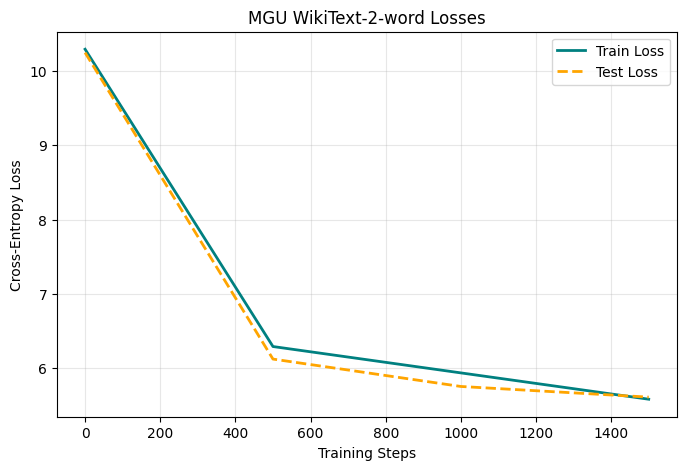

Step: 1500
Training loss: 5.581965923309326
Validation loss: 5.61024567255607
PPL measurement: 273.21135029136923


  0%|          | 0/104 [00:00<?, ?it/s]

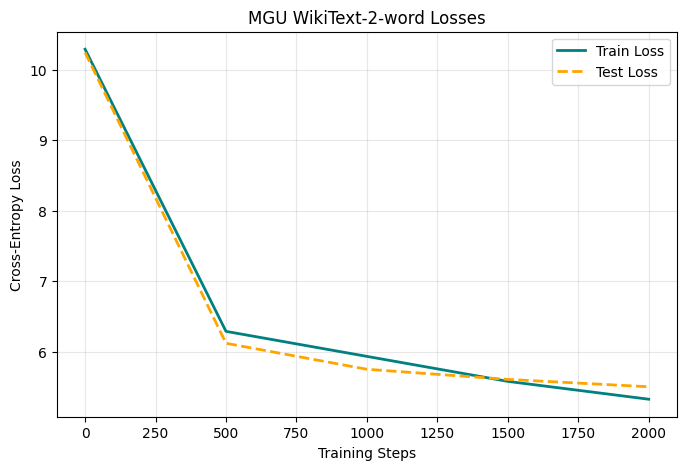

Step: 2000
Training loss: 5.328902721405029
Validation loss: 5.505215631081508
PPL measurement: 245.97148905899974


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

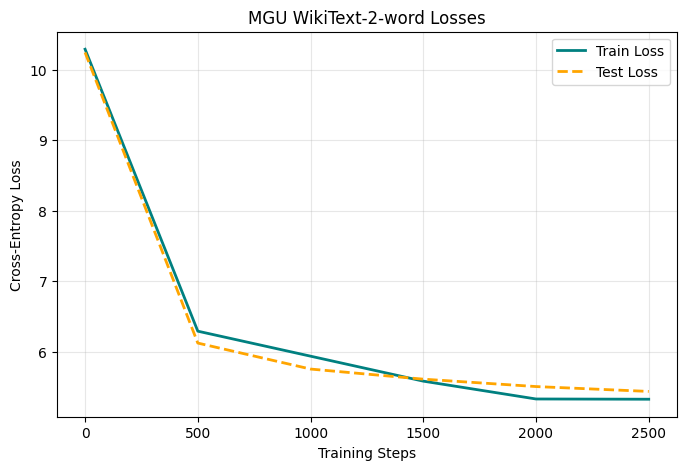

Step: 2500
Training loss: 5.325471878051758
Validation loss: 5.436060135181133
PPL measurement: 229.5360585861126


  0%|          | 0/104 [00:00<?, ?it/s]

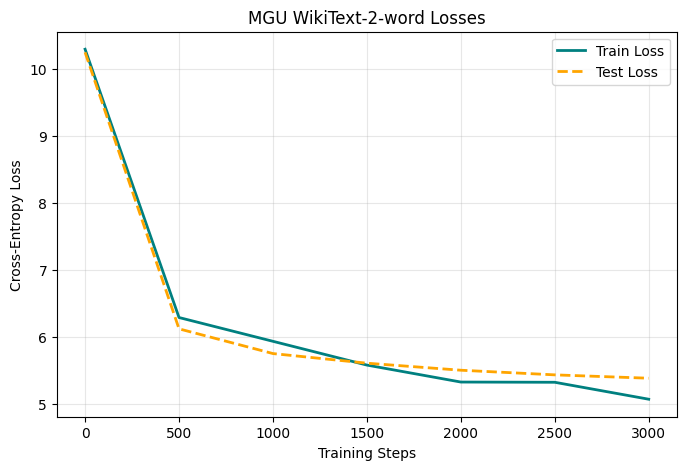

Step: 3000
Training loss: 5.072768688201904
Validation loss: 5.385928204426398
PPL measurement: 218.31264885846957


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

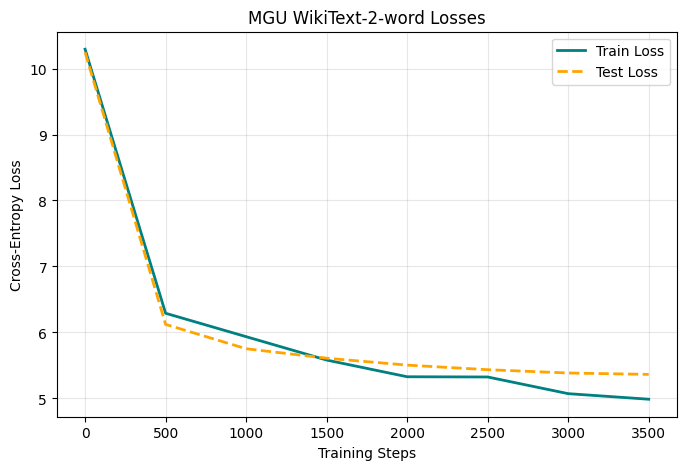

Step: 3500
Training loss: 4.988470077514648
Validation loss: 5.3646839673702535
PPL measurement: 213.7236803500758


  0%|          | 0/104 [00:00<?, ?it/s]

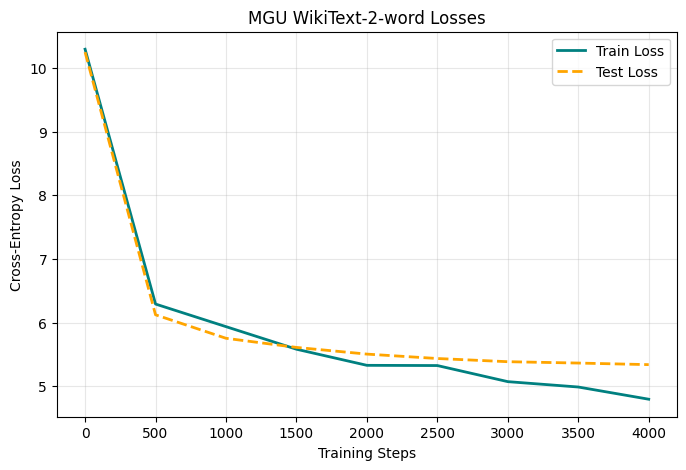

Step: 4000
Training loss: 4.796806812286377
Validation loss: 5.33979731798172
PPL measurement: 208.47045279469964


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

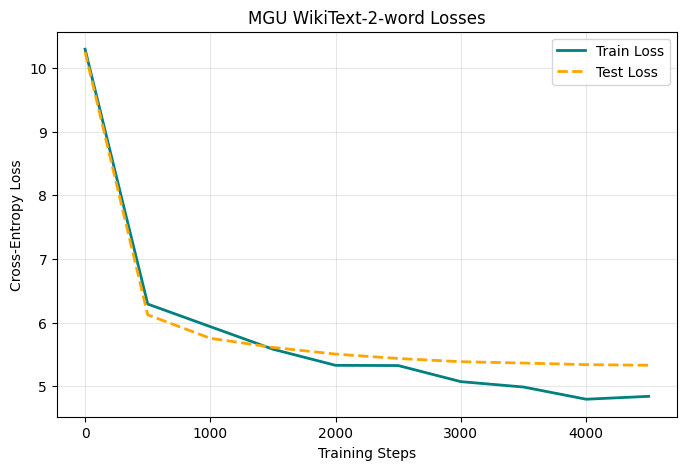

Step: 4500
Training loss: 4.842060565948486
Validation loss: 5.3299615153899556
PPL measurement: 206.43002962424654


  0%|          | 0/104 [00:00<?, ?it/s]

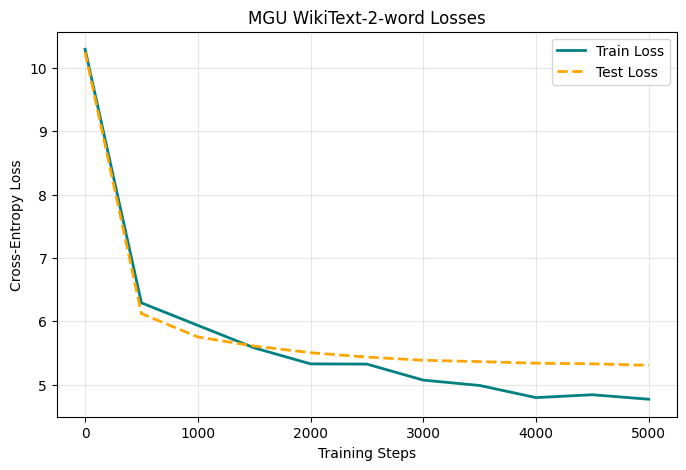

Step: 5000
Training loss: 4.771411418914795
Validation loss: 5.30620506635079
PPL measurement: 201.58377793166343


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

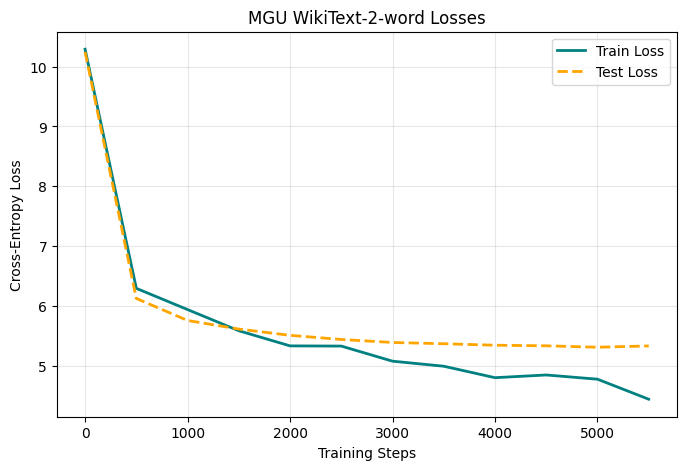

Step: 5500
Training loss: 4.43637228012085
Validation loss: 5.327982187271118
PPL measurement: 206.02184096494915


  0%|          | 0/104 [00:00<?, ?it/s]

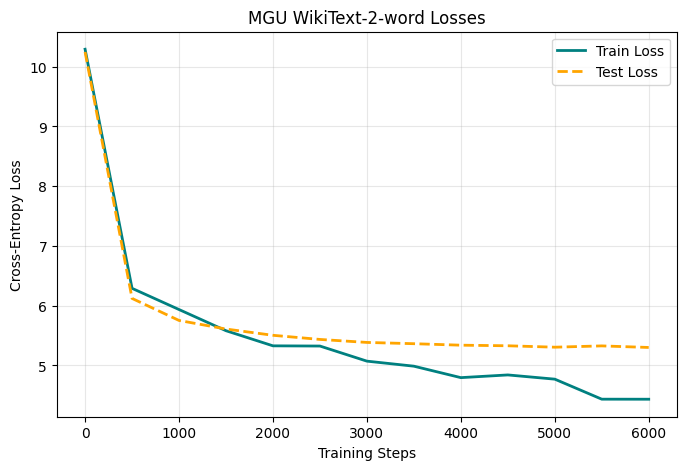

Step: 6000
Training loss: 4.4355998039245605
Validation loss: 5.301645274345692
PPL measurement: 200.6666902861341


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

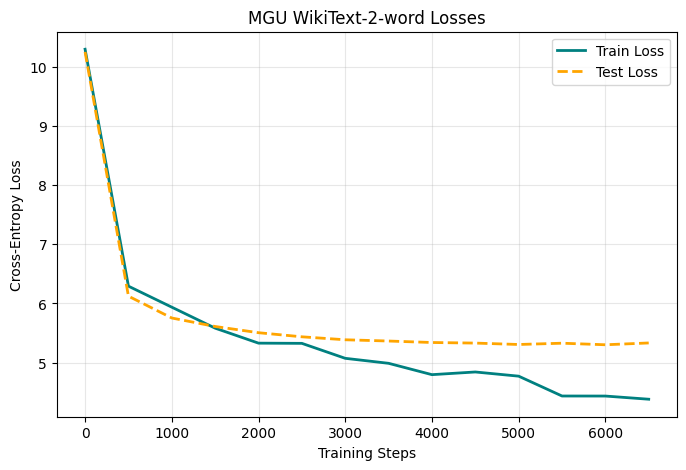

Step: 6500
Training loss: 4.382007598876953
Validation loss: 5.332144994002122
PPL measurement: 206.88125762291003


  0%|          | 0/104 [00:00<?, ?it/s]

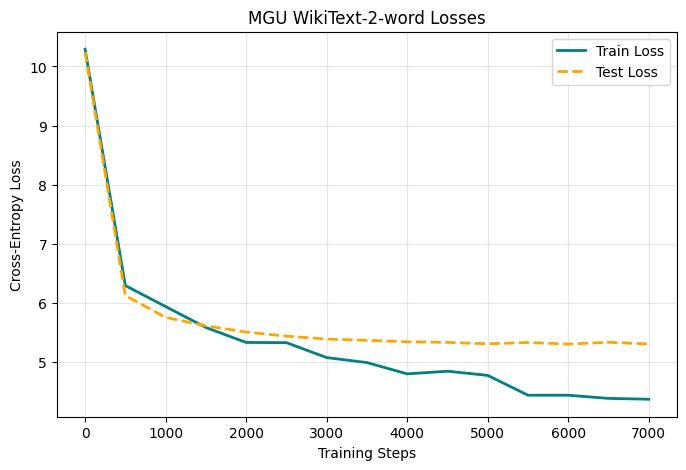

Step: 7000
Training loss: 4.367904186248779
Validation loss: 5.303530945227696
PPL measurement: 201.04543860610622


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

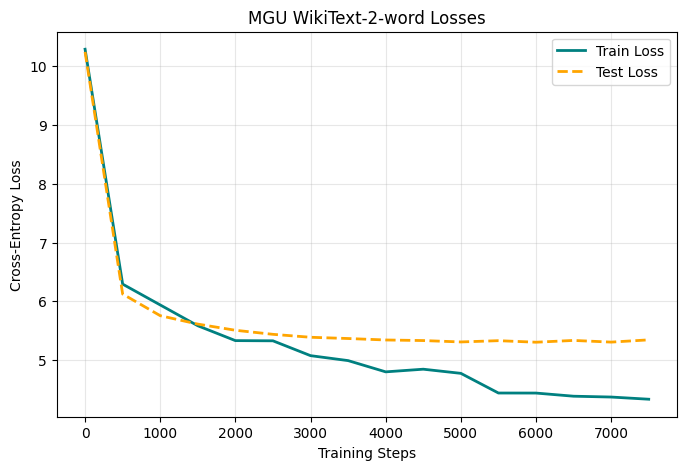

Step: 7500
Training loss: 4.330691337585449
Validation loss: 5.341840212161724
PPL measurement: 208.89677118282674


  0%|          | 0/104 [00:00<?, ?it/s]

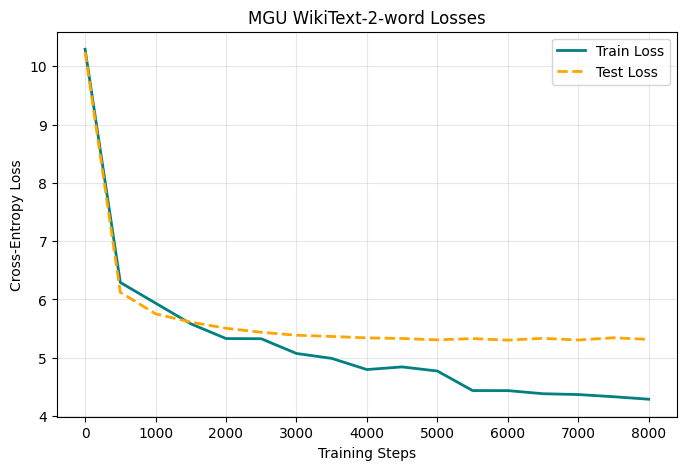

Step: 8000
Training loss: 4.28774356842041
Validation loss: 5.313843502448155
PPL measurement: 203.12945851352427


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

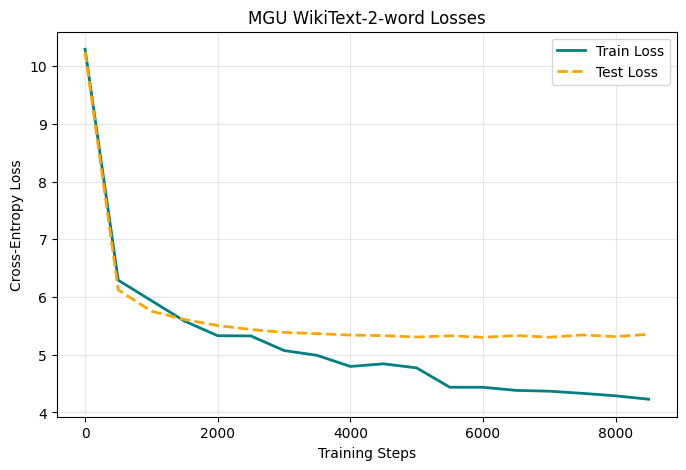

Step: 8500
Training loss: 4.228829383850098
Validation loss: 5.35261595249176
PPL measurement: 211.15996041517826


  0%|          | 0/104 [00:00<?, ?it/s]

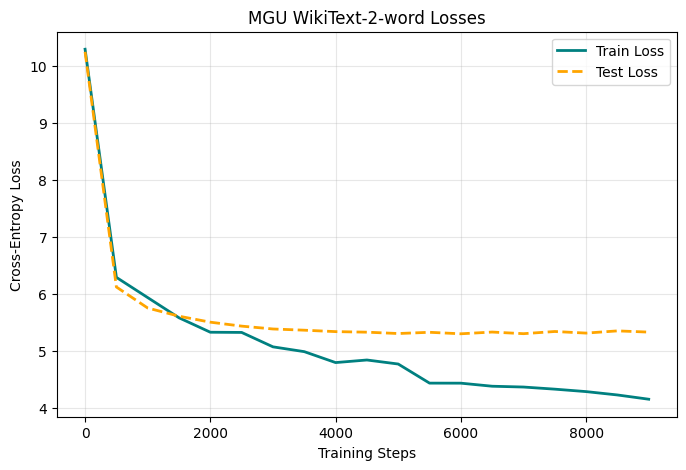

Step: 9000
Training loss: 4.154105186462402
Validation loss: 5.331204125514398
PPL measurement: 206.6867011073115


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

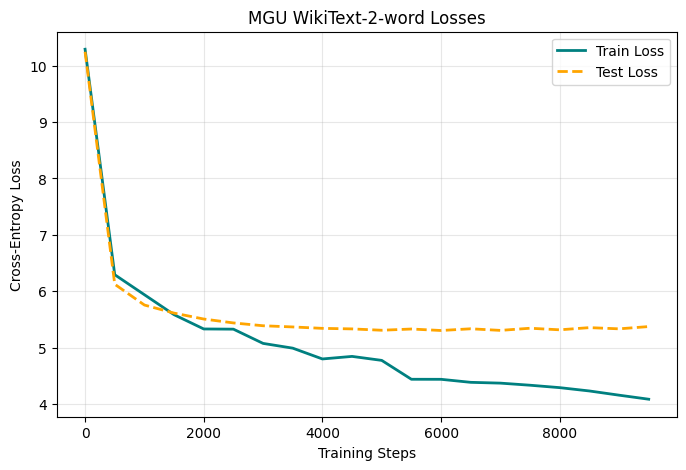

Step: 9500
Training loss: 4.082345485687256
Validation loss: 5.371549216600565
PPL measurement: 215.1959948022156


  0%|          | 0/104 [00:00<?, ?it/s]

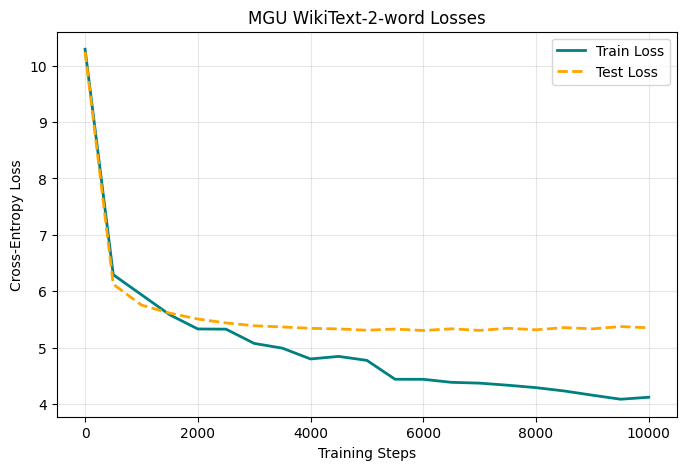

Step: 10000
Training loss: 4.117198944091797
Validation loss: 5.3494250866083
PPL measurement: 210.48725113485546


In [16]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)
lr=1e-3
epochs = 10
break_time=500
start_step =0

steps_history = []
train_history = []
test_history = []
ppl_history=[]




MGU_model = custom_models_for_lm.MGU(vocab, hid, emb, device='cuda')
opt_MGU = torch.optim.Adam(MGU_model.parameters(), lr=lr)
hid_state = MGU_model.init_hid.unsqueeze(0).expand(batch_size, -1)

for epoch in trange(epochs):

    start_step = train_model_hid_state(
        model=MGU_model,
        model_name="MGU",
        hid_state=hid_state,
        opt=opt_MGU,
        encoded_data=train_data_chunked,
        encoded_eval_data=validation_data_chunked,
        train_loss_history=train_history,
        test_loss_history=test_history,
        ppl_history=ppl_history,
        start_step=start_step,
        recorded_steps=steps_history,
        break_time=break_time,
        hid=hid,
        device='cuda'
    )


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

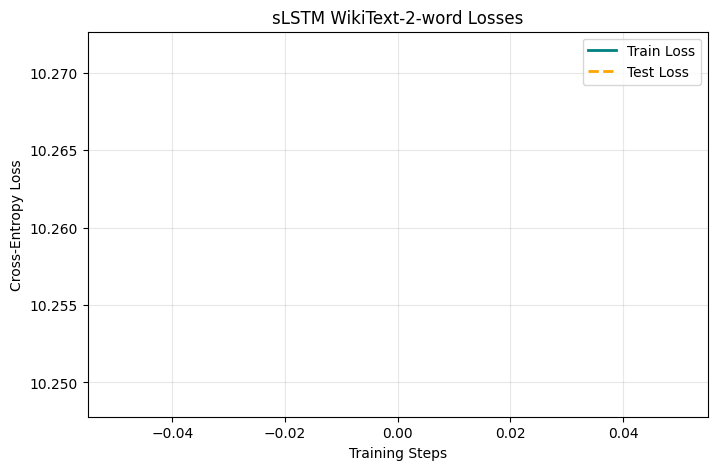

Step: 0
Training loss: 10.271537780761719
Validation loss: 10.248914150091318
PPL measurement: 28251.847992288833


  0%|          | 0/104 [00:00<?, ?it/s]

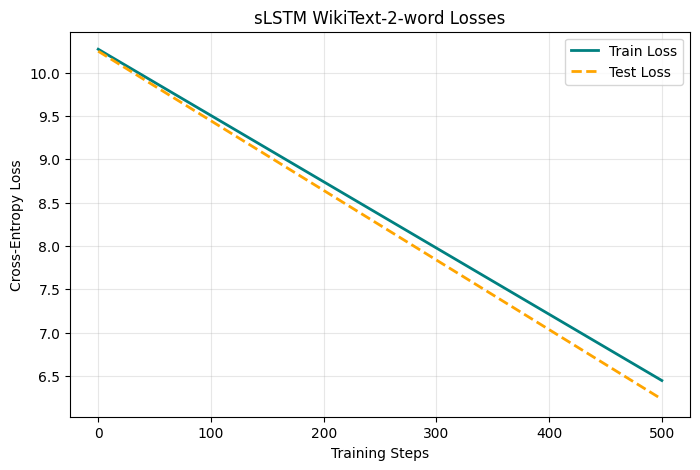

Step: 500
Training loss: 6.447432041168213
Validation loss: 6.231670044935667
PPL measurement: 508.6041664416393


  0%|          | 0/104 [00:00<?, ?it/s]

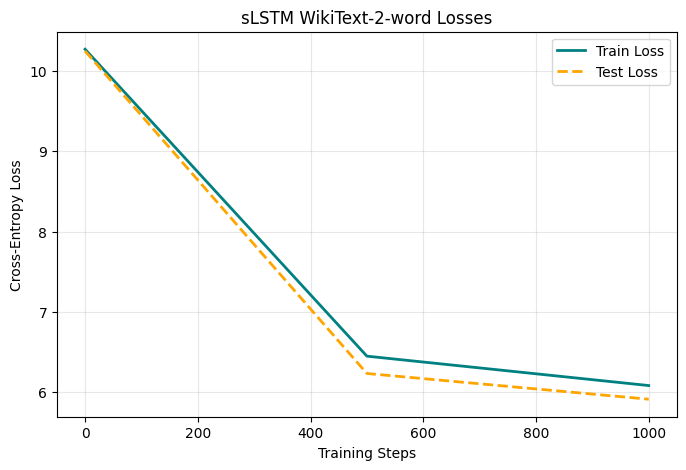

Step: 1000
Training loss: 6.081267833709717
Validation loss: 5.9109283823233385
PPL measurement: 369.0486146284909


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

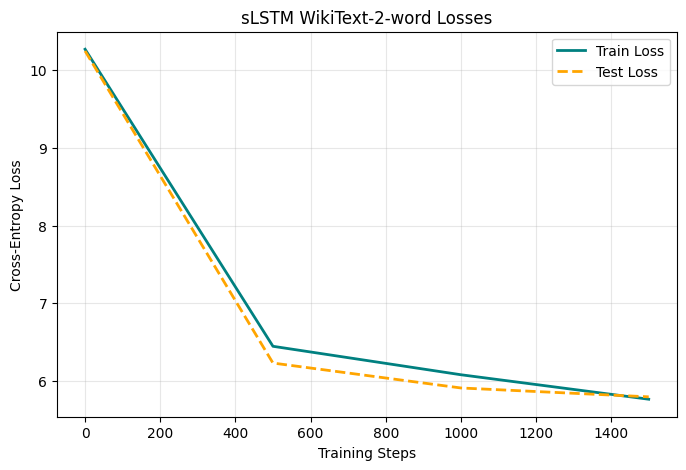

Step: 1500
Training loss: 5.7660322189331055
Validation loss: 5.796698506061848
PPL measurement: 329.2108760452971


  0%|          | 0/104 [00:00<?, ?it/s]

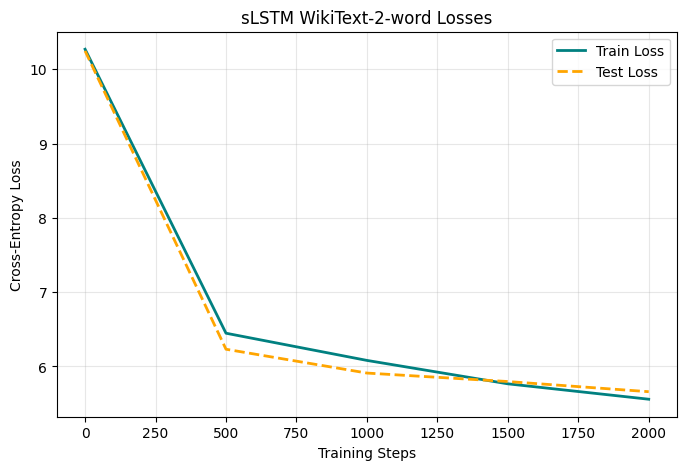

Step: 2000
Training loss: 5.558599472045898
Validation loss: 5.659818186209752
PPL measurement: 287.0964397187283


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

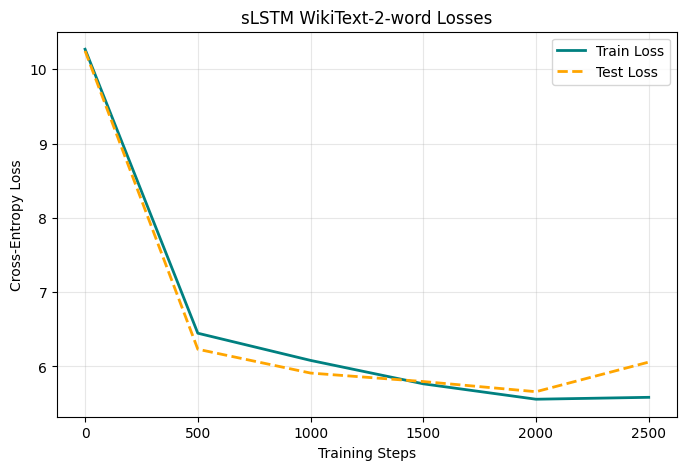

Step: 2500
Training loss: 5.584218502044678
Validation loss: 6.058560265944554
PPL measurement: 427.7591339169493


  0%|          | 0/104 [00:00<?, ?it/s]

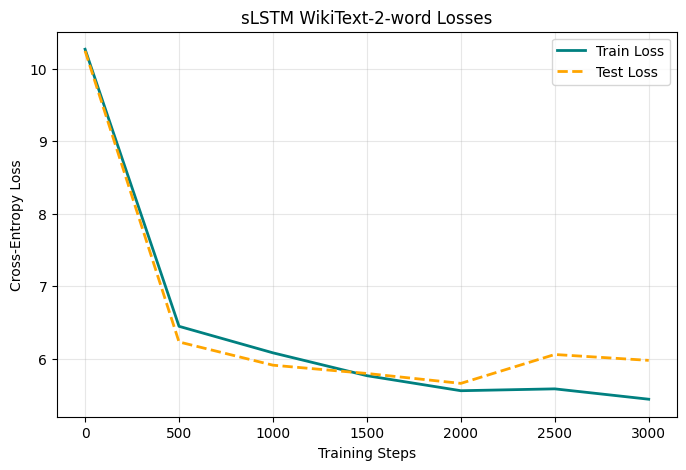

Step: 3000
Training loss: 5.441218376159668
Validation loss: 5.977354187231797
PPL measurement: 394.395489865896


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

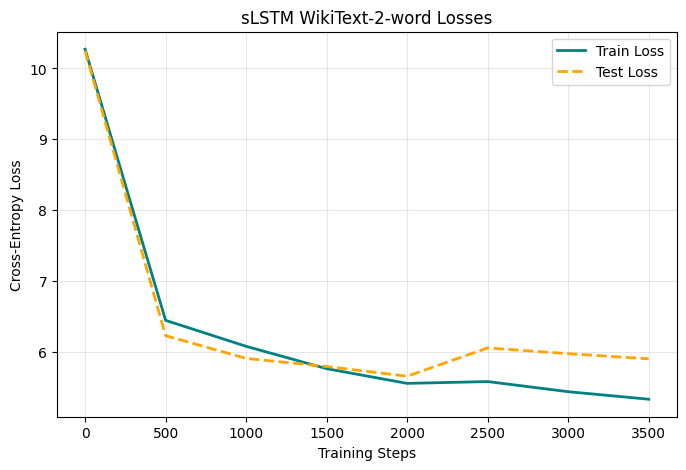

Step: 3500
Training loss: 5.335147857666016
Validation loss: 5.904776972073775
PPL measurement: 366.7854132744762


  0%|          | 0/104 [00:00<?, ?it/s]

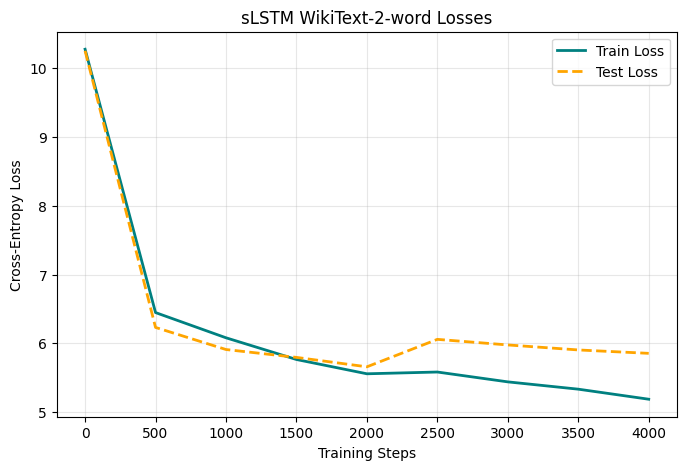

Step: 4000
Training loss: 5.189239025115967
Validation loss: 5.855382378284748
PPL measurement: 349.1083659933005


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

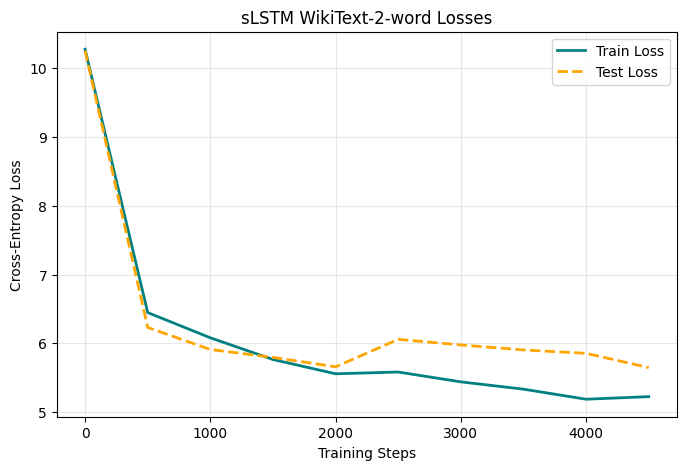

Step: 4500
Training loss: 5.226657867431641
Validation loss: 5.648131343034597
PPL measurement: 283.760718642755


  0%|          | 0/104 [00:00<?, ?it/s]

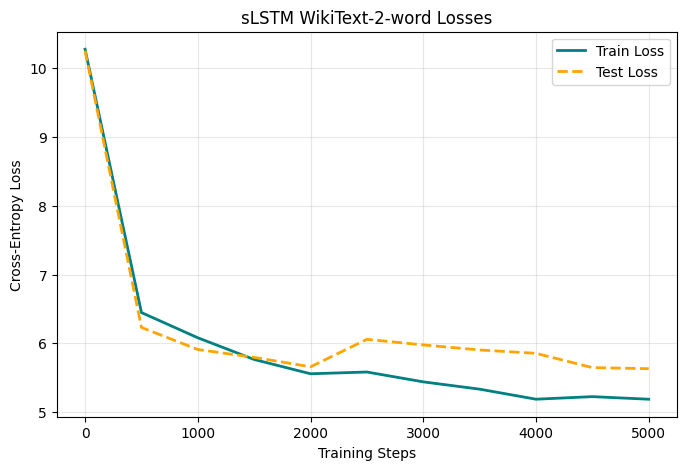

Step: 5000
Training loss: 5.189141273498535
Validation loss: 5.632586658000946
PPL measurement: 279.3838542696827


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

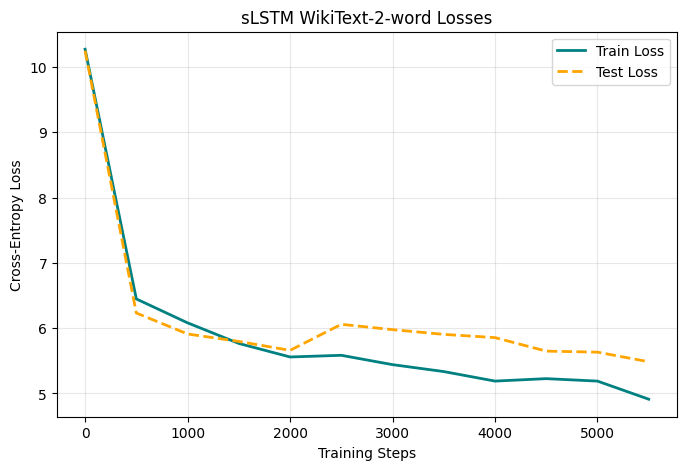

Step: 5500
Training loss: 4.911628723144531
Validation loss: 5.485443660846124
PPL measurement: 241.1559117034155


  0%|          | 0/104 [00:00<?, ?it/s]

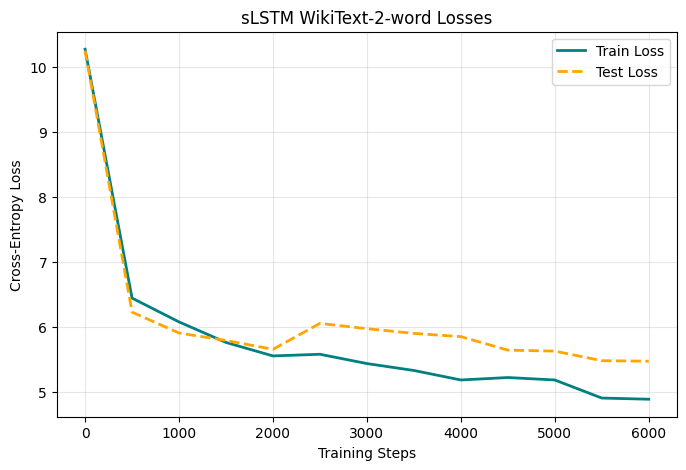

Step: 6000
Training loss: 4.893415927886963
Validation loss: 5.478000915967501
PPL measurement: 239.36771258623077


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

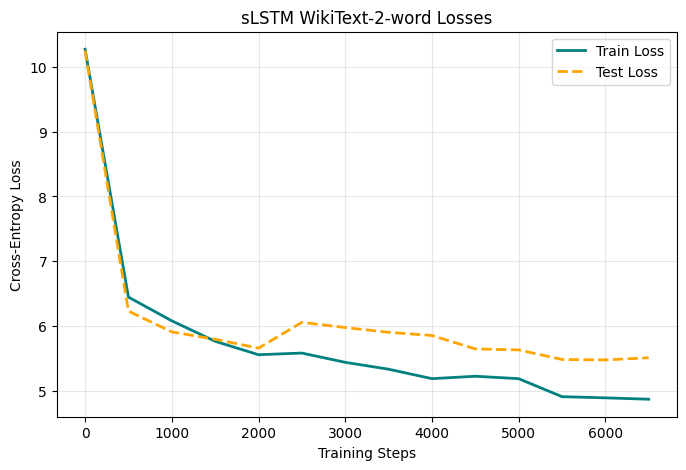

Step: 6500
Training loss: 4.872124671936035
Validation loss: 5.512340343915499
PPL measurement: 247.73022308166242


  0%|          | 0/104 [00:00<?, ?it/s]

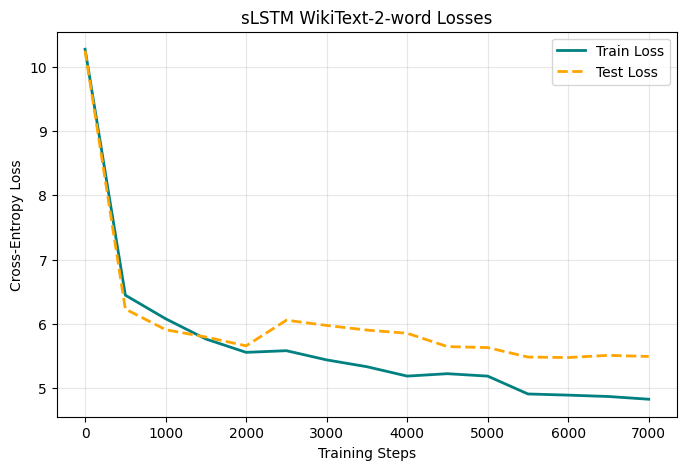

Step: 7000
Training loss: 4.829835891723633
Validation loss: 5.494345999681032
PPL measurement: 243.31234776193654


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

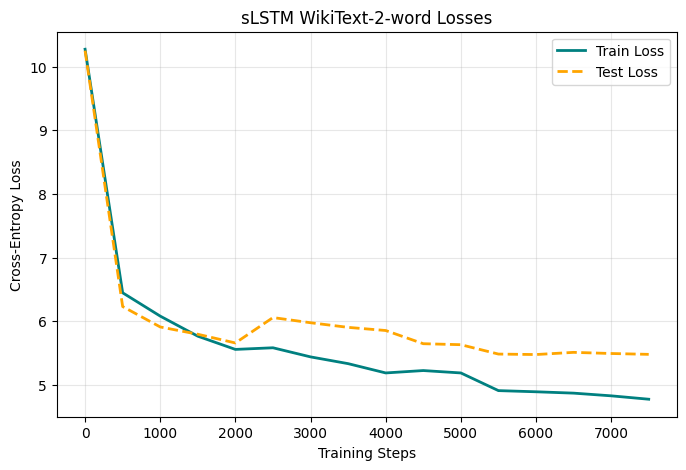

Step: 7500
Training loss: 4.776561260223389
Validation loss: 5.48090340082462
PPL measurement: 240.06348299037165


  0%|          | 0/104 [00:00<?, ?it/s]

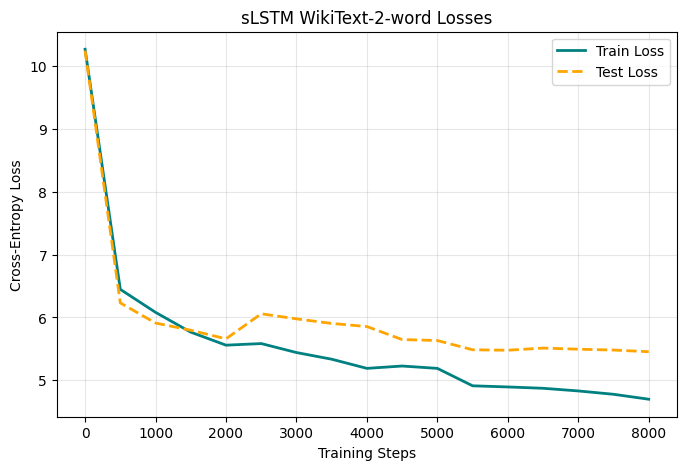

Step: 8000
Training loss: 4.697910308837891
Validation loss: 5.454527433101948
PPL measurement: 233.81435203464707


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

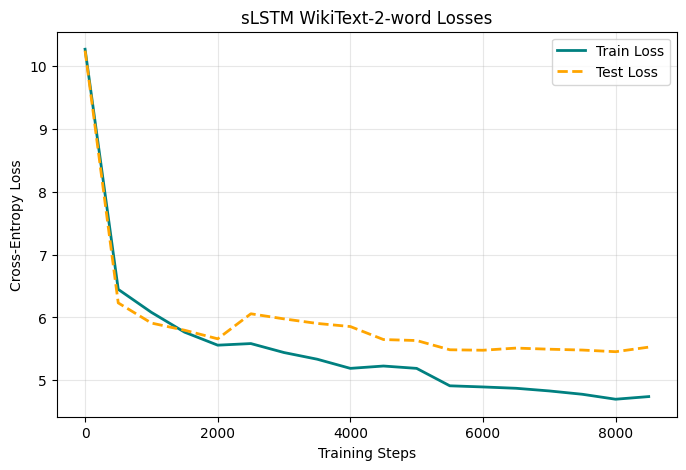

Step: 8500
Training loss: 4.739872932434082
Validation loss: 5.527434702102955
PPL measurement: 251.49791571827166


  0%|          | 0/104 [00:00<?, ?it/s]

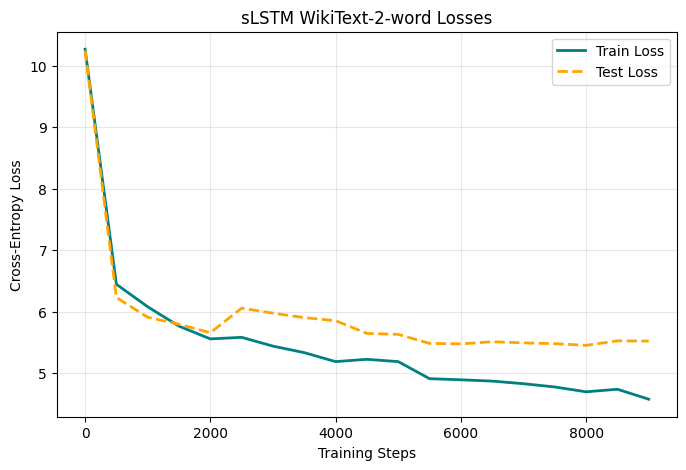

Step: 9000
Training loss: 4.57735013961792
Validation loss: 5.5230458011994
PPL measurement: 250.39653498212806


  0%|          | 0/1001 [00:00<?, ?it/s]

  0%|          | 0/104 [00:00<?, ?it/s]

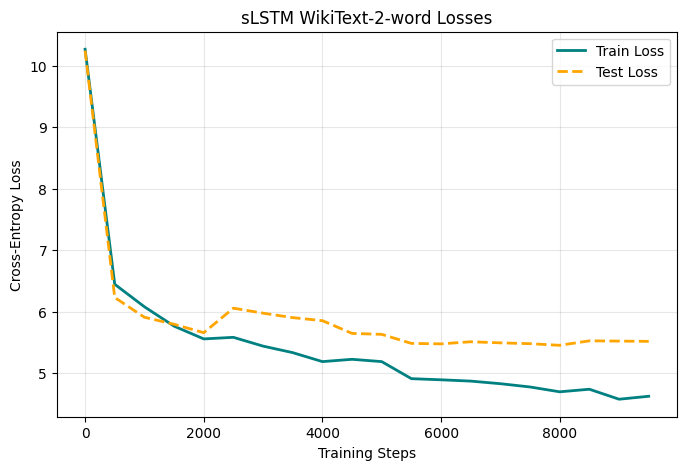

Step: 9500
Training loss: 4.625366687774658
Validation loss: 5.518464647806608
PPL measurement: 249.25205357040124


  0%|          | 0/104 [00:00<?, ?it/s]

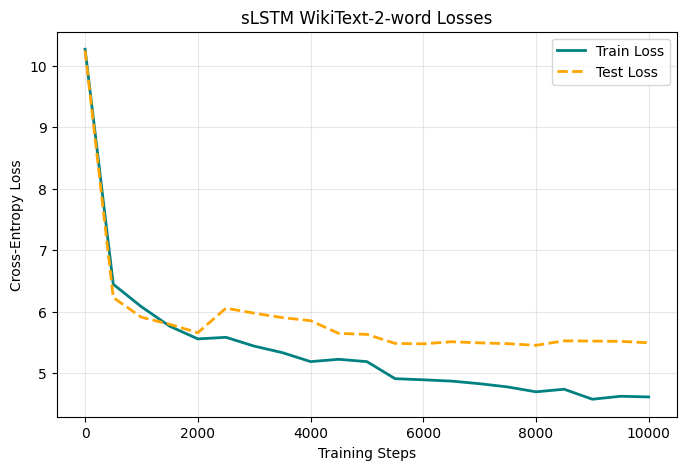

Step: 10000
Training loss: 4.614586353302002
Validation loss: 5.495289509113018
PPL measurement: 243.54202359058556


In [15]:
import custom_models_for_lm
import math

hid=256
emb=64
vocab=len(vocab_dict)
lr=1e-3
epochs = 10
break_time=500
start_step =0

steps_history = []
train_history = []
test_history = []
ppl_history=[]




sLSTM_model = custom_models_for_lm.sLSTM(vocab, hid, emb, device='cuda')
opt_sLSTM = torch.optim.Adam(sLSTM_model.parameters(), lr=lr)
cell_state = sLSTM_model.init_hid.unsqueeze(0).expand(batch_size, -1)

for epoch in trange(epochs):

    start_step = train_model(
        model=sLSTM_model,
        model_name="sLSTM",
        cell_state=cell_state,
        opt=opt_sLSTM,
        encoded_data=train_data_chunked,
        encoded_eval_data=validation_data_chunked,
        train_loss_history=train_history,
        test_loss_history=test_history,
        ppl_history=ppl_history,
        start_step=start_step,
        recorded_steps=steps_history,
        break_time=break_time,
        hid=hid,
        device='cuda'
    )
